### Process

1. Form hypotheses/develop investigation themes to explore
   * identify main booking drivers
   * see if listing image affects bookings 
3. Wrangle data
   * every variable is a column (cleaned)
   * every observation is a row (cleaned)
5. Assess the quality of data
6. Profile data
7. Explore each individual variable in the dataset
   * Exploration of each individual variable
   * Assessment of the relationship between each variable and the target variable
   * Assessment of the interaction between variables
   * Exploration of data across many dimensions
9. Assess the relationship between each variable and the target
10. Assess interactions between variables


In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import glob

# settings
sns.set(style='whitegrid')

<b>Note</b>: I initially merged all city data sets together, but didn't retain the city 'name'. Since I needed this later in my EDA, I had to add the city column into my cleaned df from the Data Wrangling portion.

In [166]:
# rebuild city lookup from raw files - EDA only, not for modeling
raw_data_path = os.path.join('..', 'data', 'raw', '*.csv')
files = glob.glob(raw_data_path)

city_lookup_dfs = []
for filepath in files:
    city_name = os.path.basename(filepath).replace('_listings_detailed.csv', '').replace('_', ' ').title()
    temp = pd.read_csv(filepath, usecols=['id'], low_memory=False)  # only load id column, fast
    temp['city'] = city_name
    city_lookup_dfs.append(temp)

city_lookup = pd.concat(city_lookup_dfs, ignore_index=True).drop_duplicates('id')

# then load your clean data as normal
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'airbnb_clean.csv'))

# merge city in
df = df.merge(city_lookup, on='id', how='left')

In [3]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_toiletries,amenity_tv,amenity_view_city,amenity_view_nature,amenity_view_other,amenity_view_water,amenity_washer,amenity_wifi,amenity_workspace,city
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,0,0,0,0,1,0,1,1,0,Asheville
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,1,0,0,0,0,0,0,1,0,Asheville
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,0,0,0,0,0,0,0,1,0,Asheville
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,1,1,0,0,0,0,1,1,1,Asheville
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,1,1,0,0,0,0,1,1,1,Asheville


In [4]:
df.shape

(268387, 75)

## EDA Goals + Hypotheses

Identify target variables: Bookings + Price
Identify drivers of target variables

Example:

Larger properties → higher price
Amenities → higher bookings
Location → strong effect

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,268387.0,2.605231e+17,3.476394e+17,6.0,27465371.5,49183255.0,6.663249e+17,8.929324e+17
host_id,268387.0,1.600196e+08,1.589328e+08,23.0,24569483.0,102409966.0,2.701044e+08,5.150207e+08
room_type_hotel_room,268387.0,3.796756e-03,6.150085e-02,0.0,0.0,0.0,0.000000e+00,1.000000e+00
room_type_private_room,268387.0,2.370532e-01,4.252760e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
room_type_shared_room,268387.0,9.128609e-03,9.510684e-02,0.0,0.0,0.0,0.000000e+00,1.000000e+00
...,...,...,...,...,...,...,...,...
amenity_view_other,268387.0,4.375771e-02,2.045559e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
amenity_view_water,268387.0,4.440975e-02,2.060041e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
amenity_washer,268387.0,7.134511e-01,4.521497e-01,0.0,0.0,1.0,1.000000e+00,1.000000e+00
amenity_wifi,268387.0,9.813590e-01,1.352537e-01,0.0,1.0,1.0,1.000000e+00,1.000000e+00


### Plot histograms of summary stats

In [6]:
# Separate columns by type
id_cols = ['id', 'host_id']
amenity_cols = [col for col in df.columns if 'amenity' in col.lower()]

skip = set(id_cols + amenity_cols)
plot_cols_all = [c for c in df.columns if c not in skip]

binary_cols = [c for c in plot_cols_all if df[c].nunique() <= 2]
continuous_cols = [c for c in plot_cols_all if df[c].nunique() > 2]
plot_cols = continuous_cols + binary_cols

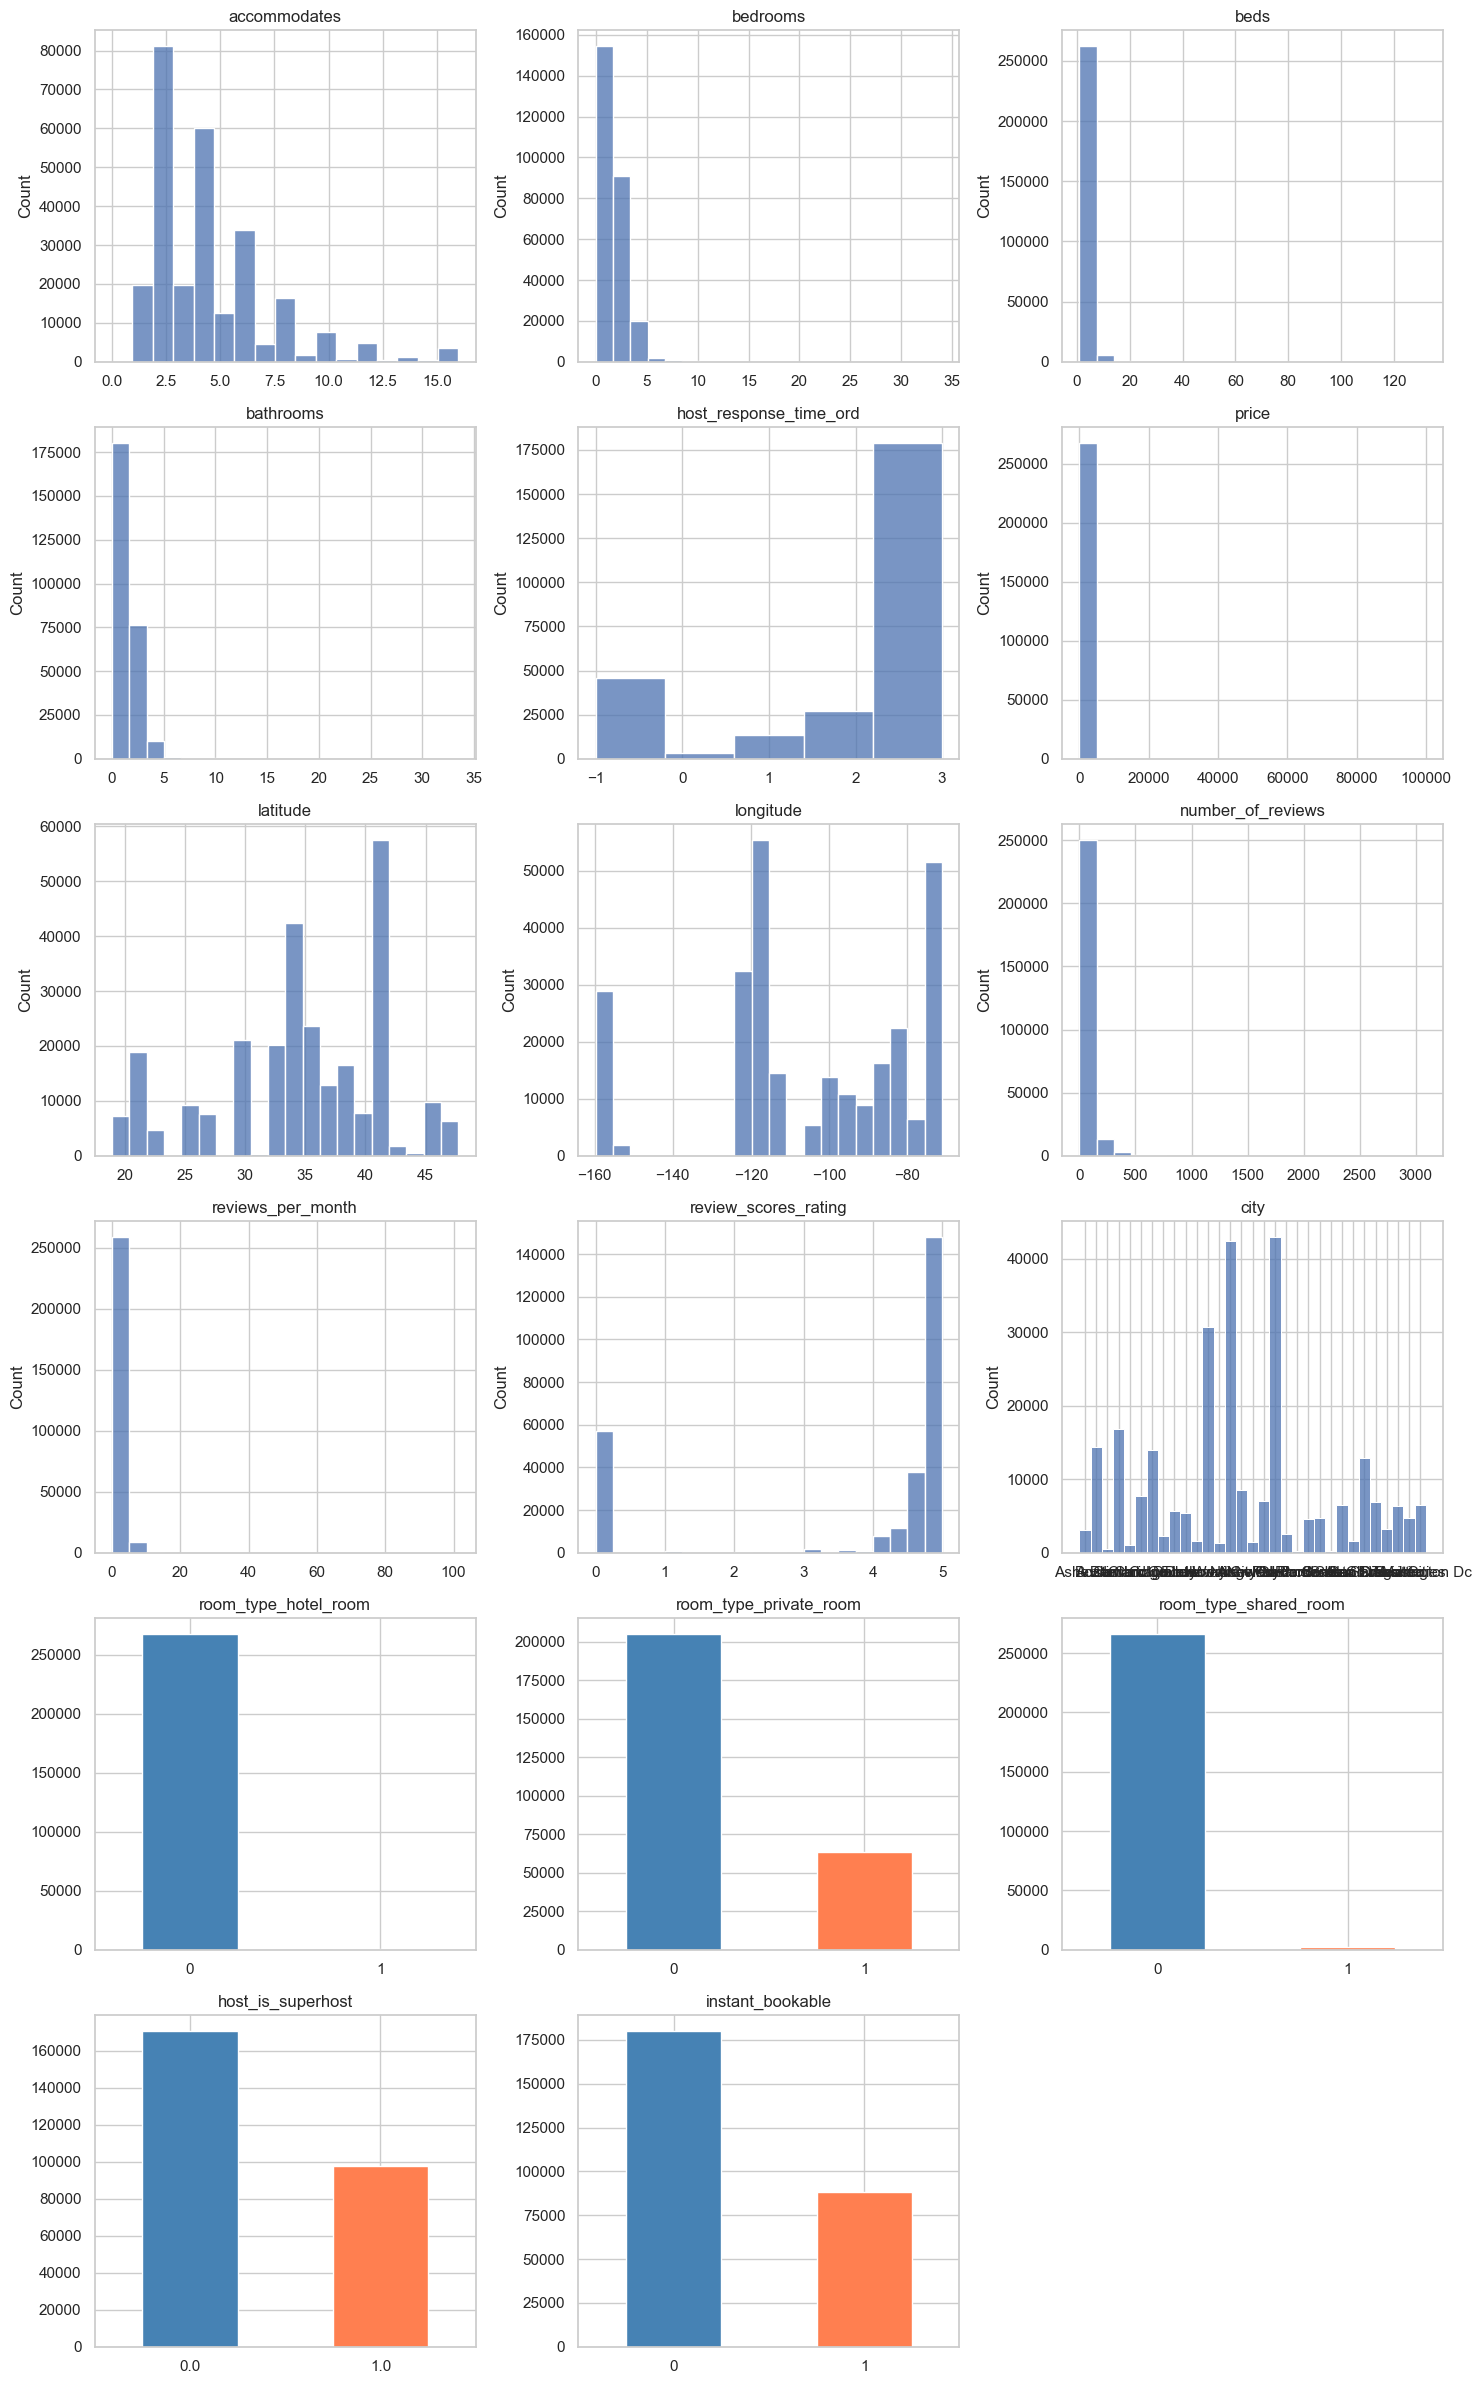

In [7]:
n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    if col in binary_cols:
        df[col].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    else:
        bins = min(df[col].nunique(), 20)
        sns.histplot(df[col], kde=False, bins=bins, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
np.log(df.price)

C:\Users\cococ\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


0         4.605170
1         4.605170
2         4.189655
3         3.806662
4         4.605170
            ...   
268382    5.147494
268383    6.173786
268384    5.153292
268385    4.406719
268386    4.682131
Name: price, Length: 268387, dtype: float64

### Analysis
* Most variables are heavily right-skewed, with the majority of listings concentrated at lower values and a small number of extreme outliers. This is clearly shown in price, number of reviews, and beds.
* Will do log scaling before modeling
* Will review outliers

In [9]:
# make copies of columns to perform log on 

df['price_log'] = np.log1p(df['price'])
df['number_of_reviews_log'] = np.log1p(df['number_of_reviews'])
df['beds_log'] = np.log1p(df['beds'])
df['accommodates_log'] = np.log1p(df['accommodates'])
df['bedrooms_log'] = np.log1p(df['bedrooms'])
df['bathrooms_log'] = np.log1p(df['bathrooms'])

In [10]:
# columns to transform
skewed_cols = [
    'price',
    'number_of_reviews',
    'beds',
    'accommodates',
    'bedrooms',
    'bathrooms']

In [11]:
# log transformed
for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

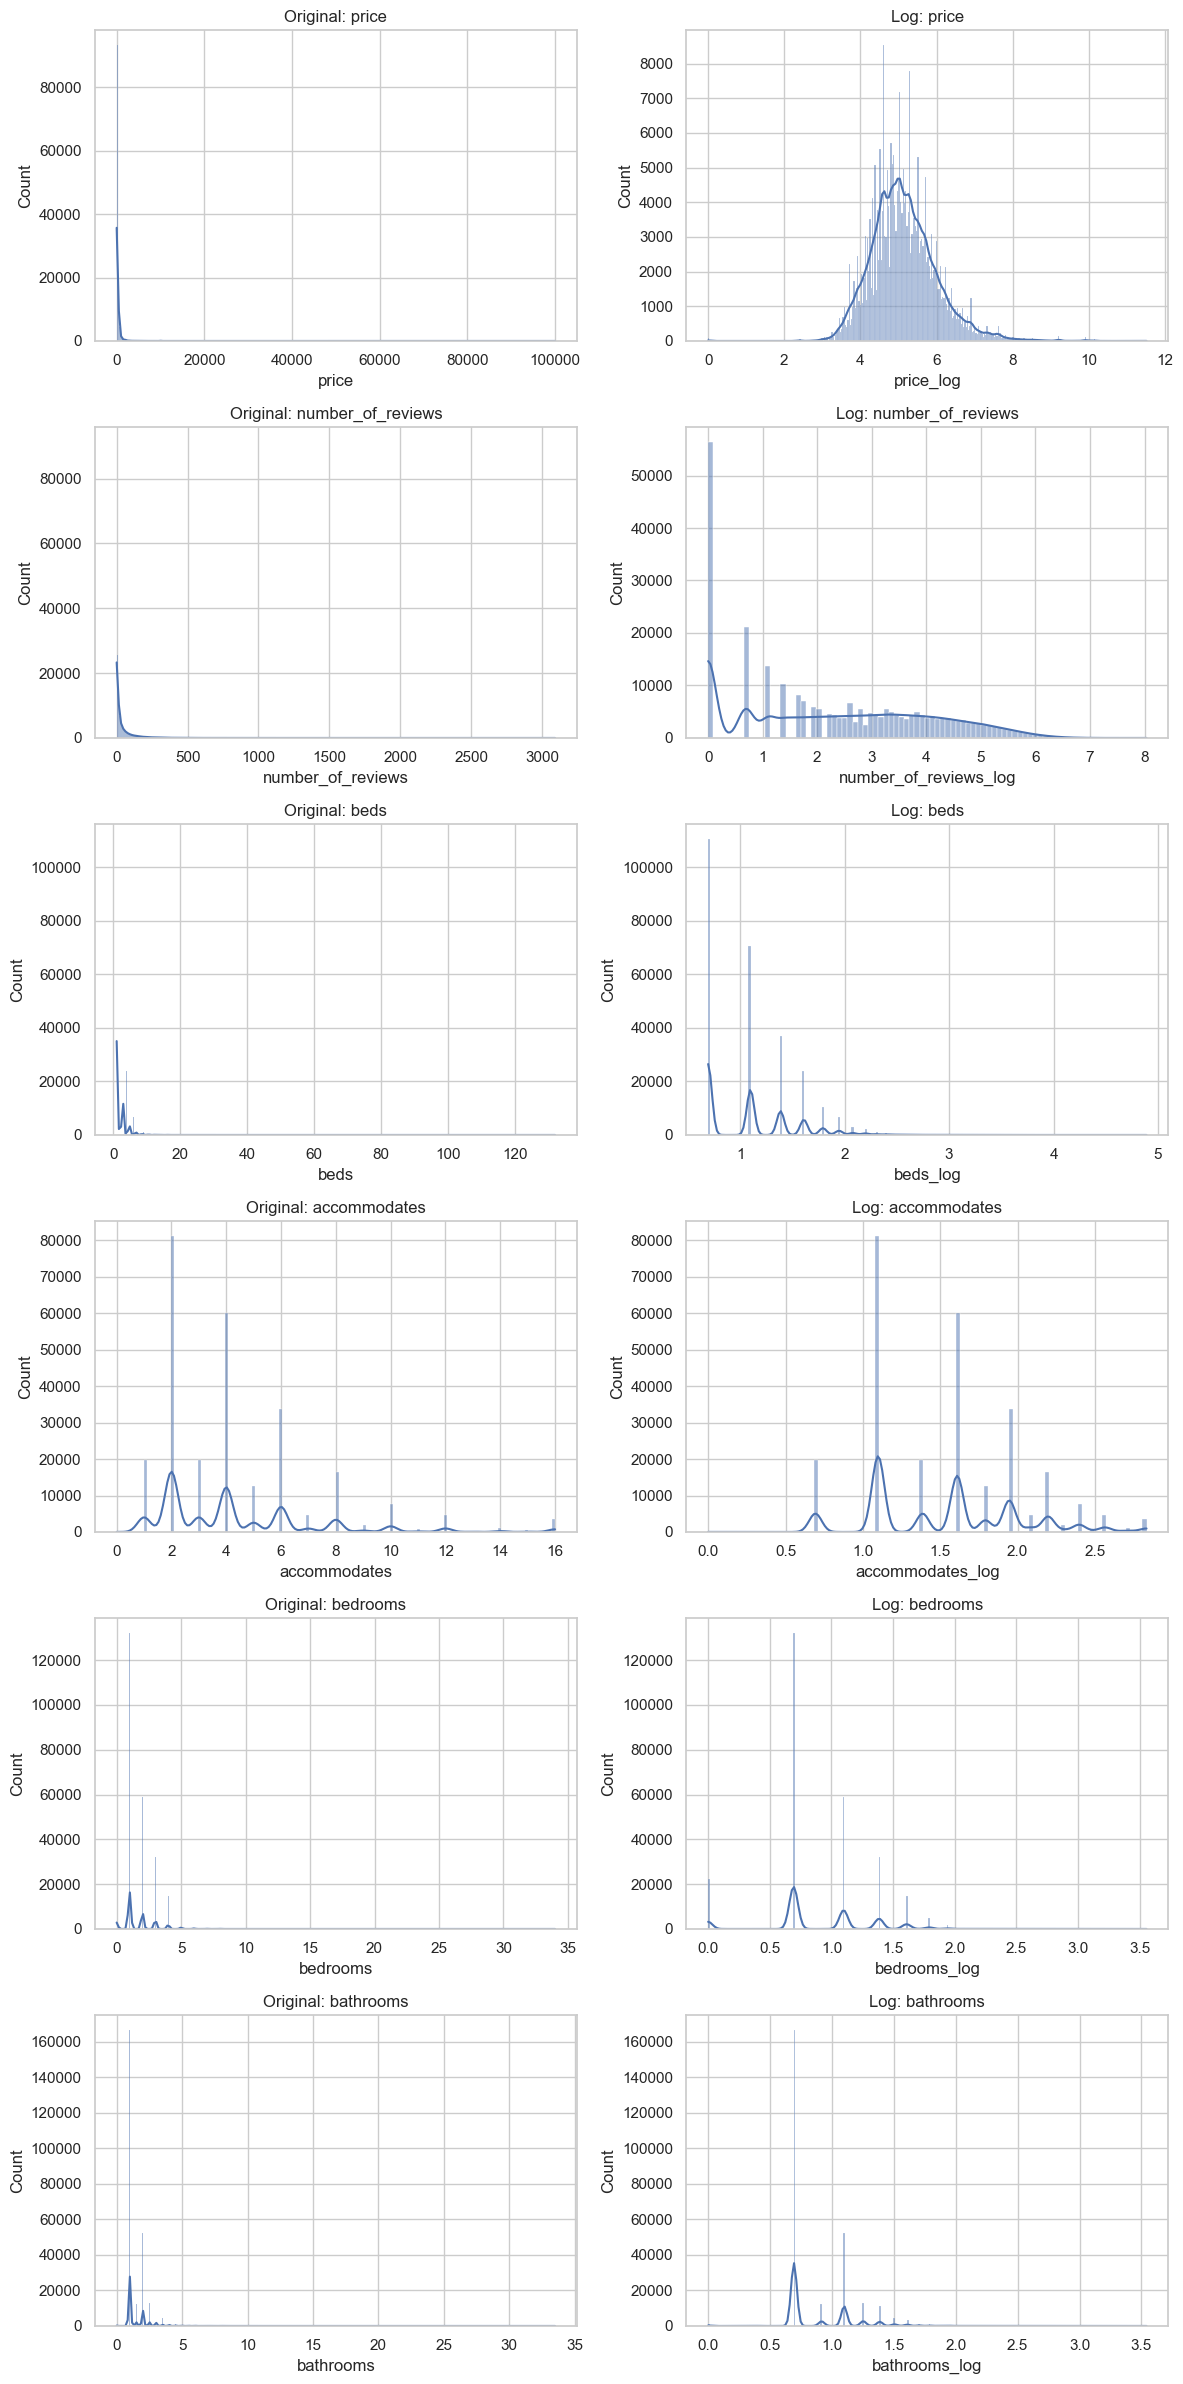

In [12]:
# compare before/after

fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(12, 4 * len(skewed_cols)))

for i, col in enumerate(skewed_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original: {col}')
    
    sns.histplot(df[f'{col}_log'], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f'Log: {col}')

plt.tight_layout()
plt.show()

In [13]:
df['price_log'] = np.log1p(df['price'])
df['number_of_reviews_log'] = np.log1p(df['number_of_reviews'])

### Analysis: 
Price and number of reviews were right skewed with long tails. I applied log transformation to reduce skewn, compress outliers, and make it better for modeling. Other numeric features (beds, bedrooms, bathrooms, accommodates) were evaluated but I decided on keeping the original data since the transformation didn't signficantly change the results and the numbers are discrete and limited.

### Investigate Outliers

Before looking into feature relationships, I looked at outliers that we identified in the previous step.
Since they can influence correlation coefficients and regression models, I wanted to see if they're legit observations or errors/quality issues.

### Goals
- Identify extreme values in key continuous variables
- Determine if outliers are real listings or data errors
- Decide whether keep, remove, transform.

### Variables to Review
- Price
- Beds
- Bedrooms
- Bathrooms
- Number of Reviews
  
### Methods
1. Review boxplots for each suspect variable
2. Calculate IQR bounds / percentile cutoffs
3. Inspect top extreme observations directly
4. Make case-by-case decisions on treatment

### Questions to Consider
- Is the value feasible in the real world?
- Could this represent a luxury/large-group listing rather than bad data?
- Is the value most likely a typo, scrape issue, or malformed entry?
- Would keeping this point distort downstream analysis disproportionately?

### Deliverables
- Summary of identified outliers
- Rationale for retaining/removing/capping
- Cleaned dataframe prepared for correlation analysis

In [14]:
outlier_cols = [
    'price',
    'beds',
    'bedrooms',
    'bathrooms',
    'number_of_reviews']

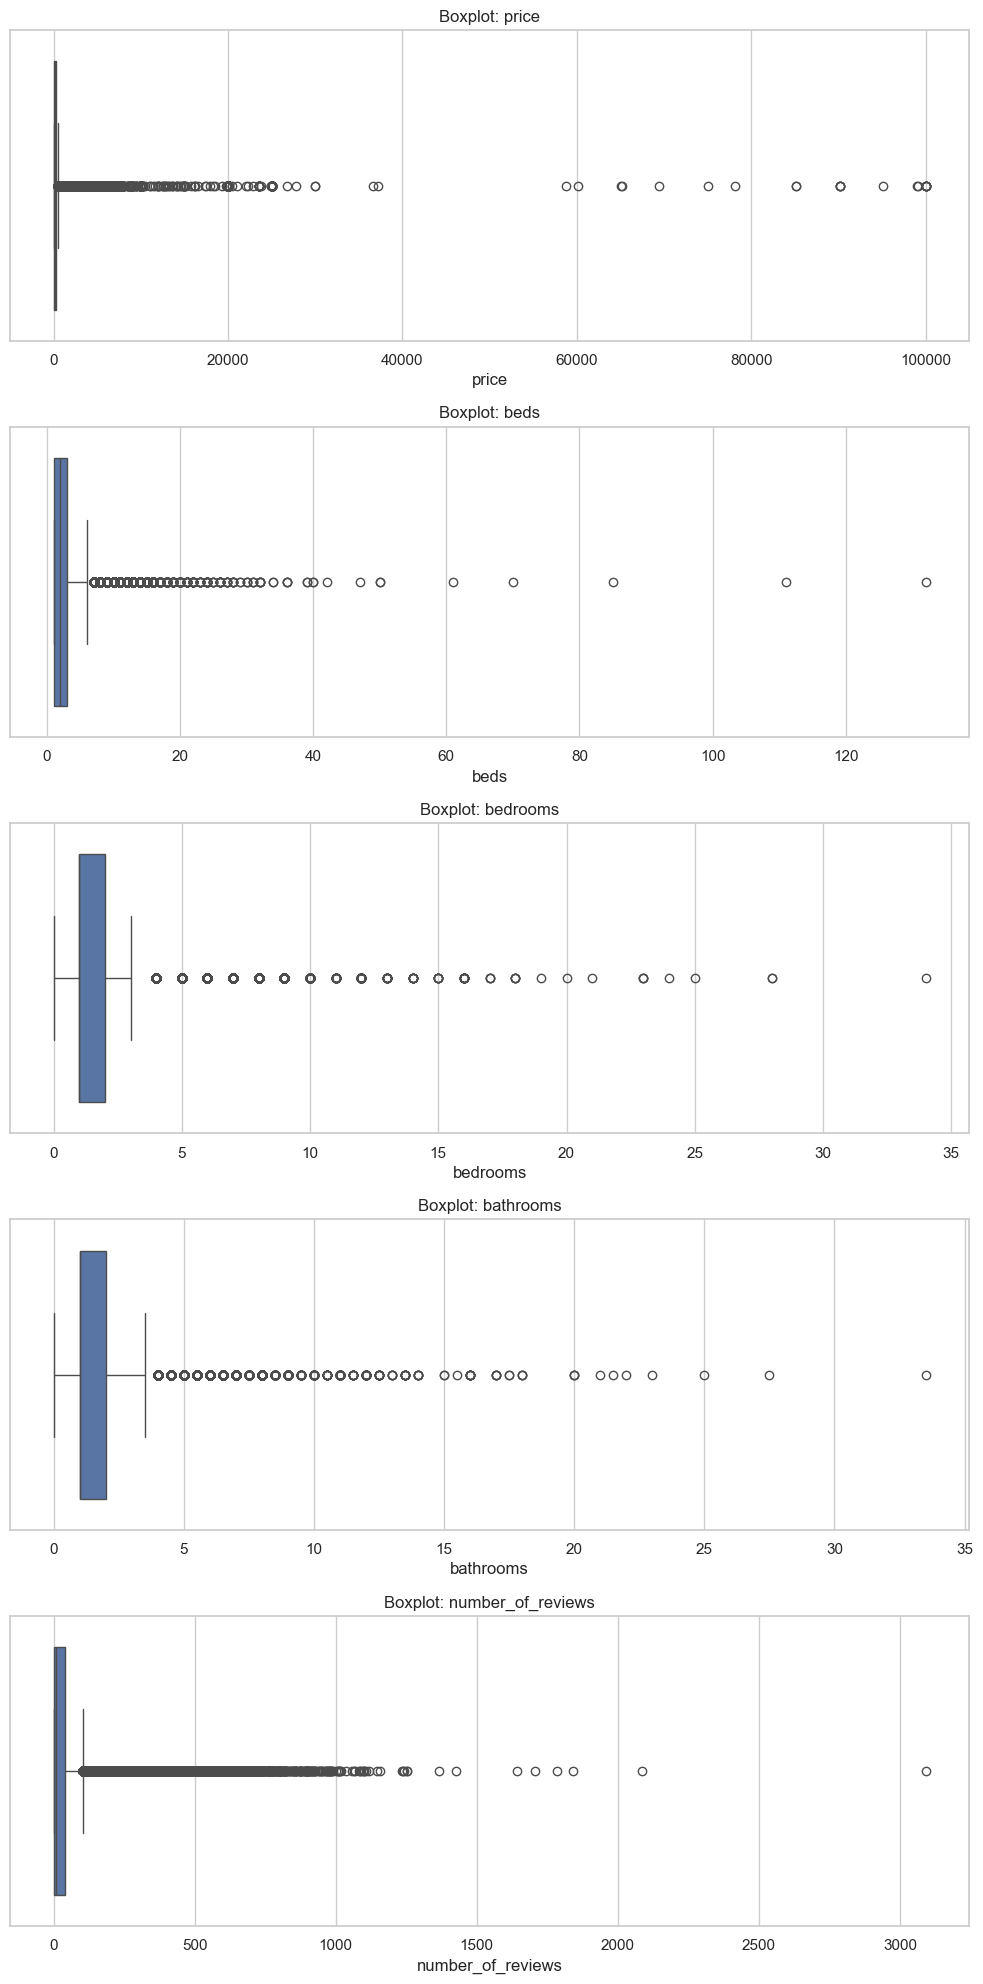

In [15]:
fig, axes = plt.subplots(len(outlier_cols), 1, figsize=(10, 4 * len(outlier_cols)))

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

In [16]:
outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    outlier_summary.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(df) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,price,96.0,275.0,179.0,-172.5,543.5,22795,8.49
1,beds,1.0,3.0,2.0,-2.0,6.0,9154,3.41
2,bedrooms,1.0,2.0,1.0,-0.5,3.5,22849,8.51
3,bathrooms,1.0,2.0,1.0,-0.5,3.5,7777,2.90
4,number_of_reviews,1.0,42.0,41.0,-60.5,103.5,30716,11.44


In [17]:
for col in outlier_cols:
    print(f'\n{col}')
    print(df[col].quantile([0.90, 0.95, 0.99, 0.995, 1.00]))


price
0.900       495.00
0.950       767.00
0.990      2028.14
0.995      3150.00
1.000    100000.00
Name: price, dtype: float64

beds
0.900      4.0
0.950      6.0
0.990      9.0
0.995     11.0
1.000    132.0
Name: beds, dtype: float64

bedrooms
0.900     3.0
0.950     4.0
0.990     6.0
0.995     6.0
1.000    34.0
Name: bedrooms, dtype: float64

bathrooms
0.900     2.5
0.950     3.0
0.990     5.0
0.995     6.0
1.000    33.5
Name: bathrooms, dtype: float64

number_of_reviews
0.900     116.0
0.950     188.0
0.990     380.0
0.995     470.0
1.000    3091.0
Name: number_of_reviews, dtype: float64


In [18]:
# look at outliers
for col in outlier_cols:
    threshold = df[col].quantile(0.995)

    cols_to_show = list(dict.fromkeys([
        col, 'id', 'price', 'beds', 'bedrooms', 'bathrooms', 'accommodates'
    ]))

    print(f'\nTop 10 rows above 99.5th percentile for {col}:')

    display(
        df[df[col] > threshold][cols_to_show]
        .sort_values(by=col, ascending=False)
        .head(10)
    )


Top 10 rows above 99.5th percentile for price:


,price,id,beds,bedrooms,bathrooms,accommodates
233855,100000.0,47475849,1.0,1.0,1.0,2
250330,100000.0,739802119944942774,1.0,1.0,1.0,1
23543,100000.0,53810192,2.0,2.0,2.0,6
104228,99999.0,53775685,1.0,1.0,1.0,2
116659,99999.0,745158970810985968,5.0,3.0,1.0,10
37335,99998.0,24894665,4.0,3.0,1.0,6
101336,99110.0,34781289,2.0,1.0,1.0,2
188006,99000.0,683438366892259448,1.0,0.0,0.5,16
217732,95117.0,579025067192833214,2.0,2.0,1.0,4
49233,90180.0,52201755,1.0,1.0,1.0,2



Top 10 rows above 99.5th percentile for beds:


,beds,id,price,bedrooms,bathrooms,accommodates
8234,132.0,36172188,4500.0,14.0,7.0,16
150883,111.0,48120470,120.0,1.0,1.0,3
238086,85.0,681816332460794907,8807.0,34.0,23.0,16
239638,70.0,793451817699585360,7586.0,28.0,5.0,16
7383,61.0,28466259,4401.0,23.0,17.0,16
128754,50.0,817309083252697088,1396.0,12.0,12.5,16
215828,50.0,33392877,1600.0,6.0,3.0,12
231160,47.0,29158495,3563.0,17.0,14.0,16
200108,42.0,2261367,2029.0,14.0,15.5,16
149852,40.0,37291927,1571.0,12.0,12.0,16



Top 10 rows above 99.5th percentile for bedrooms:


,bedrooms,id,price,beds,bathrooms,accommodates
238086,34.0,681816332460794907,8807.0,85.0,23.0,16
232646,28.0,41397615,2426.0,39.0,33.5,16
239638,28.0,793451817699585360,7586.0,70.0,5.0,16
162461,25.0,731808128137344090,566.0,24.0,25.0,16
117564,24.0,52011994,1900.0,32.0,21.0,16
119314,23.0,549518543728558414,136.0,1.0,1.0,2
163835,23.0,588262379775327987,3311.0,31.0,9.5,16
7383,23.0,28466259,4401.0,61.0,17.0,16
23734,21.0,10542314,4757.0,16.0,20.0,16
239976,20.0,822731549014682607,275.0,1.0,20.0,2



Top 10 rows above 99.5th percentile for bathrooms:


,bathrooms,id,price,beds,bedrooms,accommodates
232646,33.5,41397615,2426.0,39.0,28.0,16
229856,27.5,18415873,179.0,2.0,2.0,6
162461,25.0,731808128137344090,566.0,24.0,25.0,16
238086,23.0,681816332460794907,8807.0,85.0,34.0,16
79365,22.0,766509974173995819,1000.0,2.0,1.0,4
111265,21.5,819924881176599481,10000.0,12.0,12.0,16
117564,21.0,52011994,1900.0,32.0,24.0,16
23734,20.0,10542314,4757.0,16.0,21.0,16
127325,20.0,54278772,20125.0,10.0,9.0,16
239976,20.0,822731549014682607,275.0,1.0,20.0,2



Top 10 rows above 99.5th percentile for number_of_reviews:


,number_of_reviews,id,price,beds,bedrooms,bathrooms,accommodates
37751,3091,29819757,173.0,1.0,1.0,1.0,2
118523,2084,42409434,116.0,1.0,1.0,1.0,2
172125,1842,44799007,234.0,1.0,0.0,1.0,2
226108,1784,8357,164.0,2.0,1.0,1.0,3
46386,1705,35158303,226.0,1.0,0.0,1.0,3
184400,1642,37122502,155.0,1.0,1.0,1.0,2
152450,1425,54227245,117.0,2.0,1.0,1.0,4
65717,1367,1733052,101.0,5.0,1.0,1.0,4
250993,1251,3861673,73.0,1.0,1.0,1.0,2
147269,1251,329997,104.0,1.0,1.0,1.0,2


## Outlier Review

Outlier price listings manually reviewed to determine if they were luxury listings or anomalies. 

Findings:
* Confirmed several high-priced listings were legitimate, leave as is.
* Confirmed multiple high-priced listings were inactive/off-market listings, unusually restrictive minimum-night requirements, or pricing inconsistent with listing characteristics. Remove from dataset.
* High bed/bath count associated with entire hotel buy outs, multiple units, corporate stays, and similar offerings. The market segment may skew the majority of data, so I am going to remove those outliers from the dataset.

In [19]:
# explore the values and percentiles to see where a good cut off might be for extreme outliers
size_cols = ['price','bedrooms', 'beds', 'bathrooms']

for col in size_cols:
    print(f"\n{col}")
    print(df[col].describe(percentiles=[.90, .98, .998]))


price
count    268387.000000
mean        289.492591
std        1106.512948
min           0.000000
50%         155.000000
90%         495.000000
98%        1385.280000
99.8%      6574.876000
max      100000.000000
Name: price, dtype: float64

bedrooms
count    268387.000000
mean          1.683968
std           1.253064
min           0.000000
50%           1.000000
90%           3.000000
98%           5.000000
99.8%         8.000000
max          34.000000
Name: bedrooms, dtype: float64

beds
count    268387.000000
mean          2.363829
std           1.935089
min           1.000000
50%           2.000000
90%           4.000000
98%           8.000000
99.8%        14.000000
max         132.000000
Name: beds, dtype: float64

bathrooms
count    268387.000000
mean          1.524278
std           0.933662
min           0.000000
50%           1.000000
90%           2.500000
98%           4.000000
99.8%         8.000000
max          33.500000
Name: bathrooms, dtype: float64


remove_ids = []

In [20]:
price_mask = (
    (df['price'] > 90000))
price_cutoff = df['price'].quantile(0.995)   # or 0.99

df[price_mask][['id','price']].sort_values('price', ascending=False)

,id,price
23543,53810192,100000.0
233855,47475849,100000.0
250330,739802119944942774,100000.0
104228,53775685,99999.0
116659,745158970810985968,99999.0
37335,24894665,99998.0
101336,34781289,99110.0
188006,683438366892259448,99000.0
217732,579025067192833214,95117.0
49233,52201755,90180.0


In [21]:
# create masks
commercial_mask = (
    (df['bedrooms'] > 12) |
    (df['beds'] > 14) |
    (df['bathrooms'] > 8)
)

price_cutoff = df['price'].quantile(0.995)
price_mask = df['price'] > price_cutoff

combined_mask = price_mask | commercial_mask

# build exclusion reason before splitting (np.where handles overlaps - commercial takes priority)
exclusion_reason = np.where(
    commercial_mask, 'commercial',
    np.where(price_mask, 'price_outlier', None)
)

# save removed rows with reason attached
removed_listings = df[combined_mask].copy()
removed_listings['exclude_reason'] = exclusion_reason[combined_mask]

# cleaned dataframe
df_clean = df[~combined_mask].copy()

# quick checks
print("Price cutoff:", price_cutoff)
print("Price outliers removed:", price_mask.sum())
print("Structural outliers removed:", commercial_mask.sum())
print("Total removed:", combined_mask.sum())
print("Cleaned shape:", df_clean.shape)

removed_listings[['id', 'price', 'bedrooms', 'beds', 'bathrooms']].sort_values(
    'price', ascending=False).head(10)

Price cutoff: 3150.0
Price outliers removed: 1340
Structural outliers removed: 781
Total removed: 1982
Cleaned shape: (266405, 81)


,id,price,bedrooms,beds,bathrooms
23543,53810192,100000.0,2.0,2.0,2.0
233855,47475849,100000.0,1.0,1.0,1.0
250330,739802119944942774,100000.0,1.0,1.0,1.0
116659,745158970810985968,99999.0,3.0,5.0,1.0
104228,53775685,99999.0,1.0,1.0,1.0
37335,24894665,99998.0,3.0,4.0,1.0
101336,34781289,99110.0,1.0,2.0,1.0
188006,683438366892259448,99000.0,0.0,1.0,0.5
217732,579025067192833214,95117.0,2.0,2.0,1.0
49233,52201755,90180.0,1.0,1.0,1.0


In [22]:
(removed_listings
    .groupby('exclude_reason')[['price', 'bedrooms', 'beds', 'bathrooms']]
    .agg(['median', 'count']))

price       bedrooms         beds       bathrooms      
                median count   median count median count    median count
exclude_reason                                                          
commercial      1029.0   781      8.0   781   16.0   781       8.0   781
price_outlier   5500.0  1201      2.0  1201    3.0  1201       2.5  1201

In [23]:
df_clean.shape

(266405, 81)

<Axes: xlabel='price', ylabel='Count'>

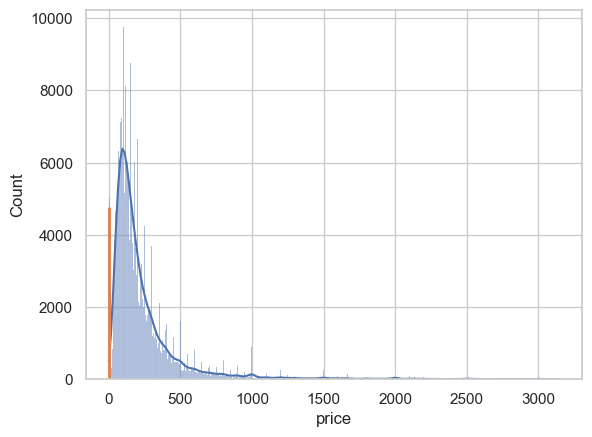

In [24]:
sns.histplot(df_clean['price'], kde=True)
sns.histplot(np.log1p(df_clean['price']), kde=True)

<Axes: >

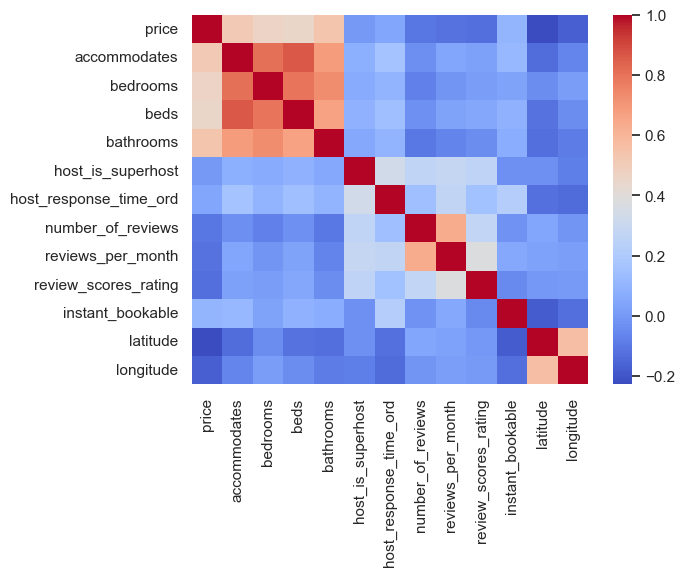

In [31]:
core_cols = [
    'price',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'host_is_superhost',
    'host_response_time_ord',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'instant_bookable',
    'latitude',
    'longitude'
]

corr = df_clean[core_cols].corr()

sns.heatmap(corr, cmap='coolwarm')

In [32]:
corr['price'].sort_values(ascending=False)

price                     1.000000
bathrooms                 0.537158
accommodates              0.518871
bedrooms                  0.464254
beds                      0.452716
instant_bookable          0.101128
host_response_time_ord    0.044317
host_is_superhost         0.000746
number_of_reviews        -0.104594
reviews_per_month        -0.122109
review_scores_rating     -0.129212
longitude                -0.175037
latitude                 -0.228159
Name: price, dtype: float64

### Create a set to house inactive listings
Since I'm filtering listings in a few different ways, I will most likely keep adding inactive listings as I go through them manually. 

In [33]:
inactive_ids = set()

### Review
I realized that encoding room type and removing 'entire home' made it harder for visualization, so I'm adding back the categorical columns to visually inspect the relationship

In [34]:
# add back columns for room types for easier visualization
df_clean['room_type'] = 'Entire home/apt'

df_clean.loc[df_clean['room_type_private_room'] == 1, 'room_type'] = 'Private room'
df_clean.loc[df_clean['room_type_shared_room'] == 1, 'room_type'] = 'Shared room'
df_clean.loc[df_clean['room_type_hotel_room'] == 1, 'room_type'] = 'Hotel room'

([0, 1, 2, 3],
 [Text(0, 0, 'Entire home/apt'),
  Text(1, 0, 'Private room'),
  Text(2, 0, 'Shared room'),
  Text(3, 0, 'Hotel room')])

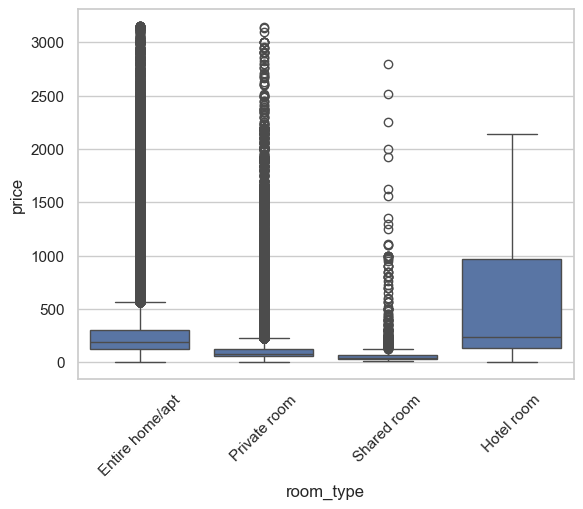

In [35]:
sns.boxplot(data=df_clean, x='room_type', y='price')
plt.xticks(rotation=45)

In [36]:
# filter shared rooms with high prices to manually check them. Use for loop to create link for faster manual checking, then mass open with chrome extension.

ids = df_clean.loc[
    (df_clean['room_type_shared_room'] == 1) & 
    (df_clean['price'] > 300), 
    'id'
]

for id in ids:
    print(f"https://www.airbnb.com/rooms/{id}")

https://www.airbnb.com/rooms/8499809
https://www.airbnb.com/rooms/8554989
https://www.airbnb.com/rooms/9500935
https://www.airbnb.com/rooms/11067353
https://www.airbnb.com/rooms/36934799
https://www.airbnb.com/rooms/14521992
https://www.airbnb.com/rooms/22245485
https://www.airbnb.com/rooms/557326590644593073
https://www.airbnb.com/rooms/558935297587570328
https://www.airbnb.com/rooms/668876766672896434
https://www.airbnb.com/rooms/804353806863519204
https://www.airbnb.com/rooms/41497802
https://www.airbnb.com/rooms/781881685799321121
https://www.airbnb.com/rooms/676271905304449028
https://www.airbnb.com/rooms/766513159464921859
https://www.airbnb.com/rooms/7275060
https://www.airbnb.com/rooms/39225953
https://www.airbnb.com/rooms/46031992
https://www.airbnb.com/rooms/25302082
https://www.airbnb.com/rooms/716743726332299007
https://www.airbnb.com/rooms/21299151
https://www.airbnb.com/rooms/30709898
https://www.airbnb.com/rooms/39223518
https://www.airbnb.com/rooms/69015
https://www.air

In [37]:
# listings marked as shared, but are actually entire homes
entire_home_ids = [22389574, 25456431]

# add inactive listings from room shares > 300
inactive_ids.update([
    9500935, 557326590644593073, 668876766672896434, 804353806863519204,
    41497802, 781881685799321121, 676271905304449028, 7275060, 39225953,
    46031992, 716743726332299007, 21299151, 69015, 33716548, 6576882,
    44398225, 39223518, 38817832, 12760823, 54117350, 603038129482973267,
    780582170025187261, 5046140, 753731123816065920, 9629756, 11628861,
    618229969802912830, 676304446219075286, 39549128, 734760353530493041,
    734751927150020653, 6937897, 628333280492085480, 32501807, 52519640,
    619144, 31439428, 32089161, 728481699229802607, 778327608834280560,
    37961305, 769636927103230399, 33396290, 38215806, 7310835, 774899,
    850935770617944118, 10929290, 48398910, 16726215, 42036525, 29826153,
    16401431, 22860173, 22972672,
])


# fix mislabeled listings on original df
df.loc[df['id'].isin(entire_home_ids), 'room_type_shared_room'] = 0

# rebuild df_clean from original df
df_clean = df[
    ~combined_mask &
    ~df['id'].isin(inactive_ids)
].copy()

print(f"Inactive remaining: {df_clean['id'].isin(inactive_ids).sum()}")  # should be 0
print(f"Clean shape: {df_clean.shape}")


Inactive remaining: 0
Clean shape: (266350, 81)


In [38]:
# manually inspect private rooms that are over 2500 nightly

ids = df_clean.loc[
    (df_clean['room_type_private_room'] == 1) & 
    (df_clean['price'] > 2500), 
    'id'
]

for id in ids:
    print(f"https://www.airbnb.com/rooms/{id}")

https://www.airbnb.com/rooms/797146518783720352
https://www.airbnb.com/rooms/35873572
https://www.airbnb.com/rooms/25373032
https://www.airbnb.com/rooms/38704036
https://www.airbnb.com/rooms/44465029
https://www.airbnb.com/rooms/47184543
https://www.airbnb.com/rooms/48719651
https://www.airbnb.com/rooms/655615634338433801
https://www.airbnb.com/rooms/739802185889404155
https://www.airbnb.com/rooms/797148744366215609
https://www.airbnb.com/rooms/849194920814650859
https://www.airbnb.com/rooms/42388908
https://www.airbnb.com/rooms/42312478
https://www.airbnb.com/rooms/609692138842591563
https://www.airbnb.com/rooms/704255194541847240
https://www.airbnb.com/rooms/39051051
https://www.airbnb.com/rooms/765963932387225699
https://www.airbnb.com/rooms/828440127039471744
https://www.airbnb.com/rooms/46707446
https://www.airbnb.com/rooms/42543983
https://www.airbnb.com/rooms/772527262639208924
https://www.airbnb.com/rooms/772530630468886320
https://www.airbnb.com/rooms/772514695053488857
https:

In [39]:
# inactive private rooms > 2500
inactive_ids.update([
    235873572, 797148744366215609, 849194920814650859, 42388908, 42312478,
    609692138842591563, 704255194541847240, 765963932387225699, 828440127039471744,
    46707446, 42543983, 772527262639208924, 772530630468886320, 772514695053488857,
    772523252167073236, 772523054615413105, 715788596004309948, 715789169240748205,
    715789838753660311, 46597956, 32476606])

### Outliers Review
<b>Price:</b> some listings were entire buyouts of hotels, bnbs, houses, multiplexs, etc. After manually inspecting, I chose to remove those listings above 99.8% range because I felt they would alter the data too much (some being priced at 100,000)

<b>High bed/bath count:</b> some listings were entire buyouts, once again, I removed the 99.8% - marking them as commercial properties

<b>Shared rooms/high price:</b> left most as is, removed inactive listings

<b>Private rooms/high price:</b> most were hotel rooms/suites, left as is. Removed inactive listings.

<b>Entire rooms/high price:</b> did not look into since there's a wide range of prices and high volume.

([0, 1, 2, 3],
 [Text(0, 0, 'Entire home/apt'),
  Text(1, 0, 'Private room'),
  Text(2, 0, 'Shared room'),
  Text(3, 0, 'Hotel room')])

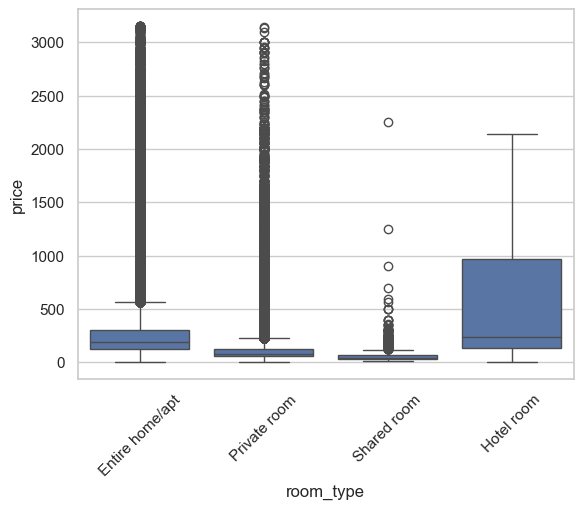

In [40]:
# add back columns for room types for easier visualization
df_clean['room_type'] = 'Entire home/apt'

df_clean.loc[df_clean['room_type_private_room'] == 1, 'room_type'] = 'Private room'
df_clean.loc[df_clean['room_type_shared_room'] == 1, 'room_type'] = 'Shared room'
df_clean.loc[df_clean['room_type_hotel_room'] == 1, 'room_type'] = 'Hotel room'

sns.boxplot(data=df_clean, x='room_type', y='price')
plt.xticks(rotation=45)

In [41]:
ids = df_clean.loc[
    (df_clean['room_type_private_room'] == 1) & 
    (df_clean['price'] > 2500),
    'id'
]

for id in ids:
    print(f"https://www.airbnb.com/rooms/{id}")

https://www.airbnb.com/rooms/797146518783720352
https://www.airbnb.com/rooms/35873572
https://www.airbnb.com/rooms/25373032
https://www.airbnb.com/rooms/38704036
https://www.airbnb.com/rooms/44465029
https://www.airbnb.com/rooms/47184543
https://www.airbnb.com/rooms/48719651
https://www.airbnb.com/rooms/655615634338433801
https://www.airbnb.com/rooms/739802185889404155
https://www.airbnb.com/rooms/797148744366215609
https://www.airbnb.com/rooms/849194920814650859
https://www.airbnb.com/rooms/42388908
https://www.airbnb.com/rooms/42312478
https://www.airbnb.com/rooms/609692138842591563
https://www.airbnb.com/rooms/704255194541847240
https://www.airbnb.com/rooms/39051051
https://www.airbnb.com/rooms/765963932387225699
https://www.airbnb.com/rooms/828440127039471744
https://www.airbnb.com/rooms/46707446
https://www.airbnb.com/rooms/42543983
https://www.airbnb.com/rooms/772527262639208924
https://www.airbnb.com/rooms/772530630468886320
https://www.airbnb.com/rooms/772514695053488857
https:

### Review correlation

<Axes: >

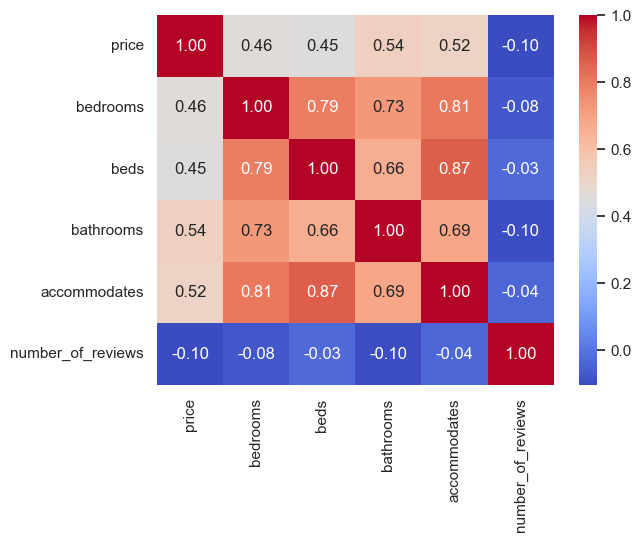

In [42]:
corr_cols = ['price', 'bedrooms', 'beds', 'bathrooms', 'accommodates', 'number_of_reviews']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [43]:
df_clean.groupby('room_type')['price'].agg(['median', 'mean', 'count'])

,median,mean,count
room_type,,,
Entire home/apt,185.0,273.742683,199746
Hotel room,239.0,610.679283,1004
Private room,78.0,137.776330,63236
Shared room,41.0,60.627750,2364


Text(0.5, 1.0, 'Price by Location')

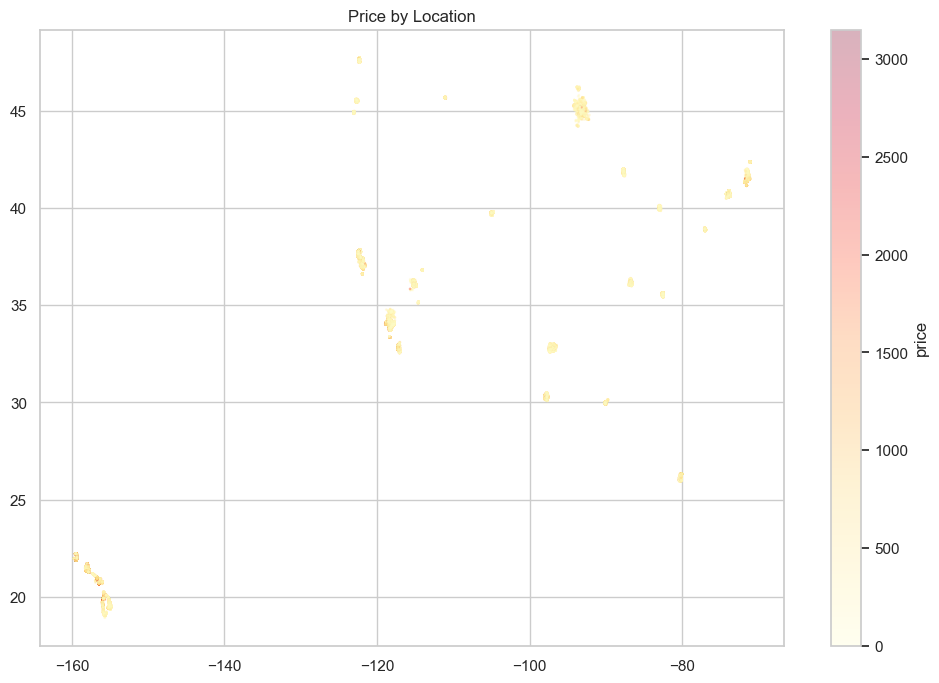

In [44]:
plt.figure(figsize=(12, 8))
plt.scatter(df_clean['longitude'], df_clean['latitude'], 
            c=df_clean['price'], cmap='YlOrRd', alpha=0.3, s=1)
plt.colorbar(label='price')
plt.title('Price by Location')

In [45]:
 # look specifically at amenities
amenity_cols = [col for col in df_clean.columns if col.startswith('amenity_')] 
amenity_corr = df_clean[amenity_cols].corrwith(df_clean['price']).sort_values(ascending=False)
amenity_corr.head(20)  # top 20 price driver amenities

amenity_pool                 0.241056
amenity_hot_tub              0.211544
amenity_bbq_grill            0.171950
amenity_dishwasher           0.165531
amenity_beach_access         0.153156
amenity_gym                  0.140045
amenity_tv                   0.123234
amenity_fireplace            0.115174
amenity_view_water           0.113246
amenity_patio_balcony        0.107188
amenity_dryer                0.098625
amenity_washer               0.097516
amenity_iron                 0.082903
amenity_hair_dryer           0.079072
amenity_ev_charger           0.078770
amenity_kids_amenities       0.077592
amenity_oven                 0.072236
amenity_coffee_maker         0.071357
amenity_sound_system         0.068043
amenity_fire_extinguisher    0.067051
dtype: float64

In [46]:
df_clean.groupby('room_type')['number_of_reviews'].agg(['median', 'mean', 'count']).round(2)

,median,mean,count
room_type,,,
Entire home/apt,11.0,42.39,199746
Hotel room,7.0,52.05,1004
Private room,5.0,33.02,63236
Shared room,3.0,21.78,2364


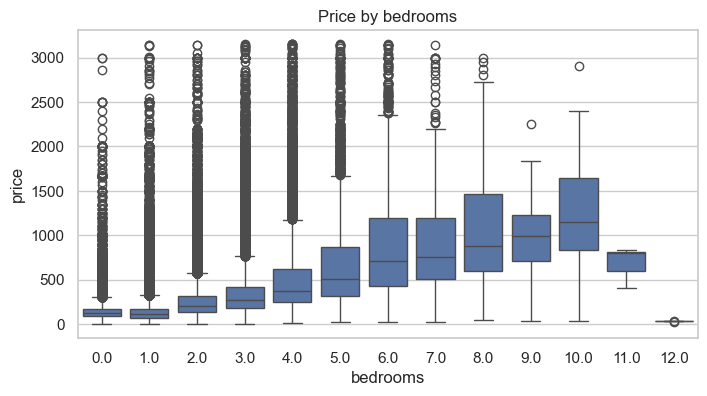

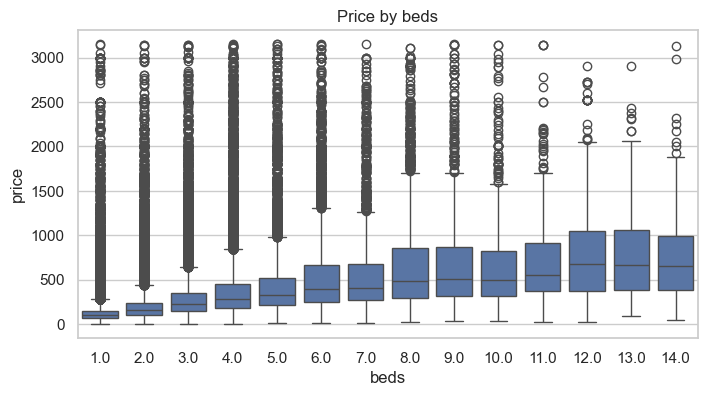

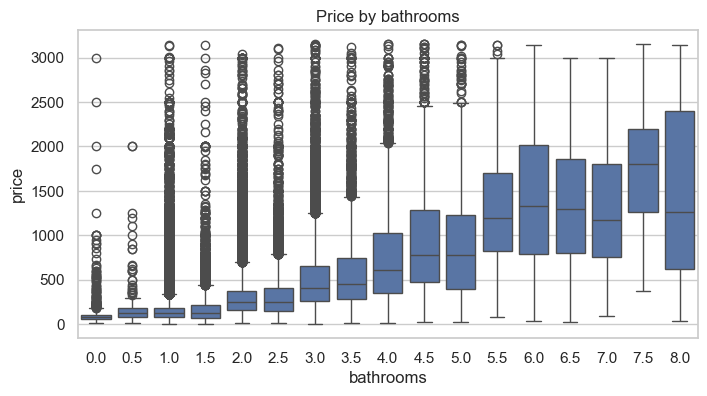

In [53]:
structural_cols = ['bedrooms', 'beds']

for col in structural_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_clean, x=col, y='price')
    plt.title(f'Price by {col}')
    plt.show()

### Location Analysis

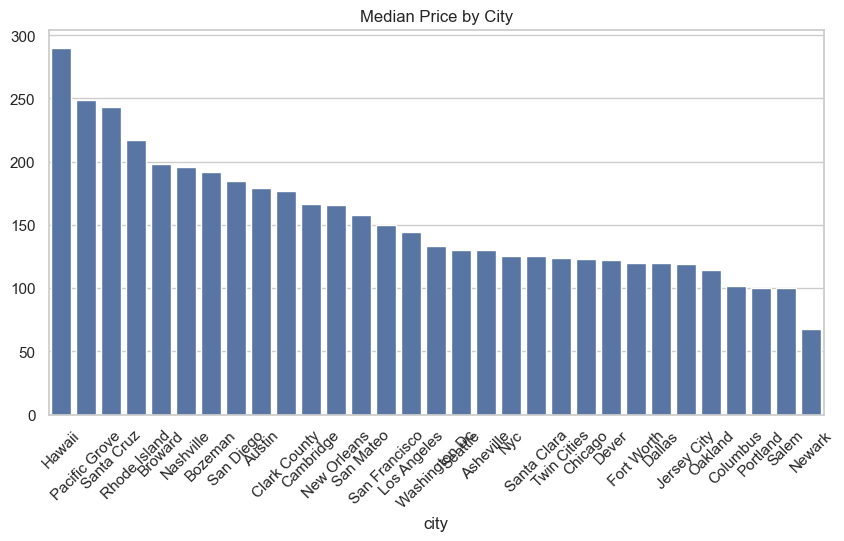

In [54]:
city_price = (
    df_clean.groupby('city')['price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(x=city_price.index, y=city_price.values)
plt.xticks(rotation=45)
plt.title('Median Price by City')
plt.show()

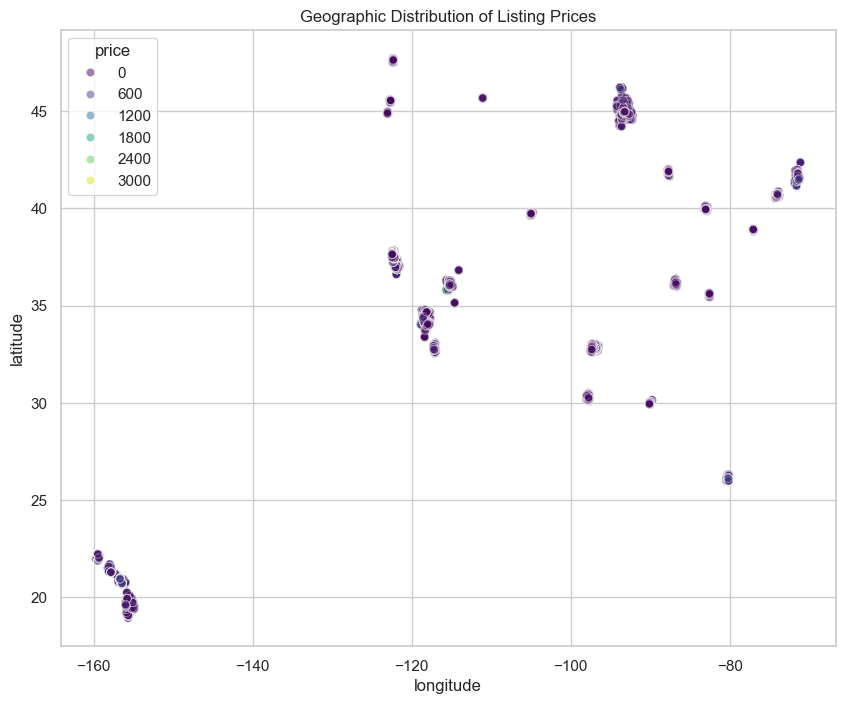

In [58]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df_clean,
    x='longitude',
    y='latitude',
    hue='price',
    palette='viridis',
    alpha=0.5
)
plt.title('Geographic Distribution of Listing Prices')
plt.show()

In [64]:
city_summary = df_clean.groupby('city').agg({
    'price':'median',
    'reviews_per_month':'median'
}).sort_values('price', ascending=False)

In [66]:
city_summary.sort_values(by='reviews_per_month', ascending=False)

,price,reviews_per_month
city,,
Asheville,130.0,1.880
Columbus,102.0,1.750
Nashville,196.0,1.500
Portland,100.0,1.400
Fort Worth,120.0,1.300
New Orleans,166.0,1.250
Seattle,130.0,1.150
Santa Cruz,243.0,1.140
Bozeman,192.0,1.070


In [71]:
city_summary = (
    df_clean.groupby('city')
    .agg(
        median_price=('price', 'median'),
        mean_price=('price', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        mean_reviews_per_month=('reviews_per_month', 'mean'),
        listing_count=('id', 'count')
    )
    .sort_values('median_price', ascending=False)
)

city_summary

,median_price,mean_price,median_reviews_per_month,mean_reviews_per_month,listing_count
city,,,,,
Hawaii,290.0,416.710587,0.480,1.001028,30320
Pacific Grove,249.0,289.322727,0.535,1.493682,220
Santa Cruz,243.0,301.790826,1.140,1.826006,1635
Rhode Island,217.0,309.665889,0.650,1.148819,4717
Broward,198.0,279.717860,0.980,1.392596,16786
Nashville,196.0,250.361761,1.500,1.988120,8337
Bozeman,192.0,238.629358,1.070,1.694899,545
San Diego,185.0,282.821046,1.000,1.649737,12791
Austin,179.0,276.119307,0.550,1.234671,14249


### Booking vs Demand

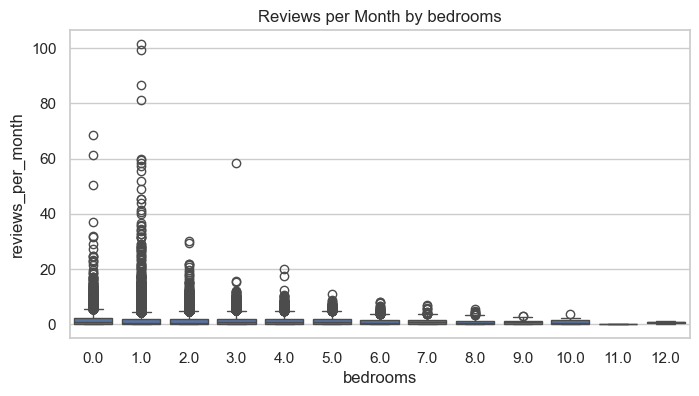

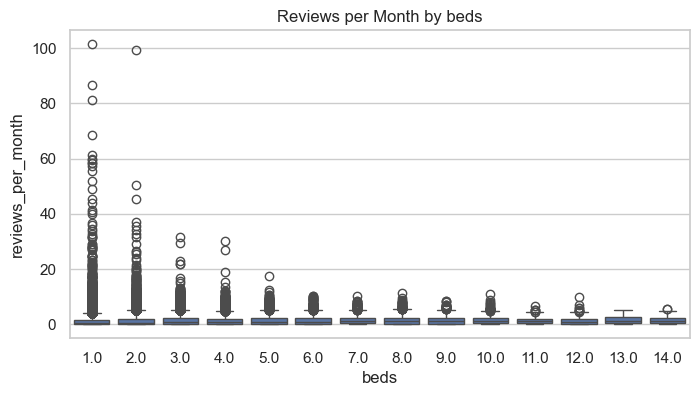

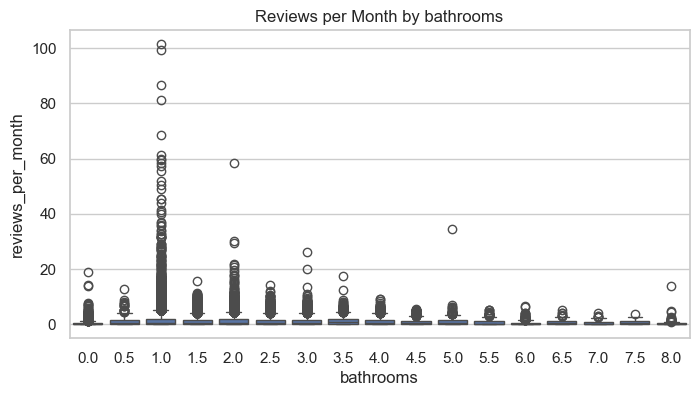

In [61]:
for col in structural_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_clean, x=col, y='reviews_per_month')
    plt.title(f'Reviews per Month by {col}')
    plt.show()

### Amenity Analysis

In [59]:
amenity_cols = [col for col in df_clean.columns if col.startswith('amenity_')]

amenity_price_uplift = {}

for col in amenity_cols:
    if df_clean[col].nunique() == 2:
        uplift = df_clean.groupby(col)['price'].median().diff().iloc[-1]
        amenity_price_uplift[col] = uplift

amenity_price_uplift = pd.Series(amenity_price_uplift).sort_values(ascending=False)

amenity_price_uplift.head(20)

amenity_view_water        135.0
amenity_beach_access      116.0
amenity_hot_tub           105.0
amenity_pool               96.0
amenity_tv                 82.0
amenity_dishwasher         77.0
amenity_bbq_grill          75.0
amenity_ev_charger         62.0
amenity_gym                55.0
amenity_washer             54.0
amenity_view_nature        51.0
amenity_patio_balcony      50.0
amenity_sound_system       50.0
amenity_dryer              50.0
amenity_fireplace          50.0
amenity_game_console       49.0
amenity_blender            48.0
amenity_kids_amenities     47.0
amenity_oven               47.0
amenity_hair_dryer         46.0
dtype: float64

In [62]:
amenity_demand_uplift = {}

for col in amenity_cols:
    uplift = df_clean.groupby(col)['reviews_per_month'].median().diff().iloc[-1]
    amenity_demand_uplift[col] = uplift

pd.Series(amenity_demand_uplift).sort_values(ascending=False).head(20)

amenity_cleaning_supplies    0.93
amenity_coffee_maker         0.90
amenity_cooking_basics       0.90
amenity_refrigerator         0.90
amenity_fan                  0.89
amenity_self_checkin         0.87
amenity_kids_amenities       0.87
amenity_microwave            0.87
amenity_toaster              0.83
amenity_hot_water            0.81
amenity_bed_linens           0.80
amenity_stove                0.79
amenity_parking_free         0.72
amenity_outdoor_space        0.70
amenity_hair_dryer           0.69
amenity_private_entrance     0.69
amenity_toiletries           0.68
amenity_essentials           0.67
amenity_patio_balcony        0.66
amenity_hangers              0.63
dtype: float64

In [77]:
top_price_amenities = amenity_price_uplift.head(10).index.tolist()

top_price_amenities

['amenity_view_water',
 'amenity_beach_access',
 'amenity_hot_tub',
 'amenity_pool',
 'amenity_tv',
 'amenity_dishwasher',
 'amenity_bbq_grill',
 'amenity_ev_charger',
 'amenity_gym',
 'amenity_washer']

In [80]:
# highest listing count
top_cities = df_clean['city'].value_counts().head(8).index.tolist()

top_cities

['Nyc',
 'Los Angeles',
 'Hawaii',
 'Broward',
 'Austin',
 'Clark County',
 'San Diego',
 'Nashville']

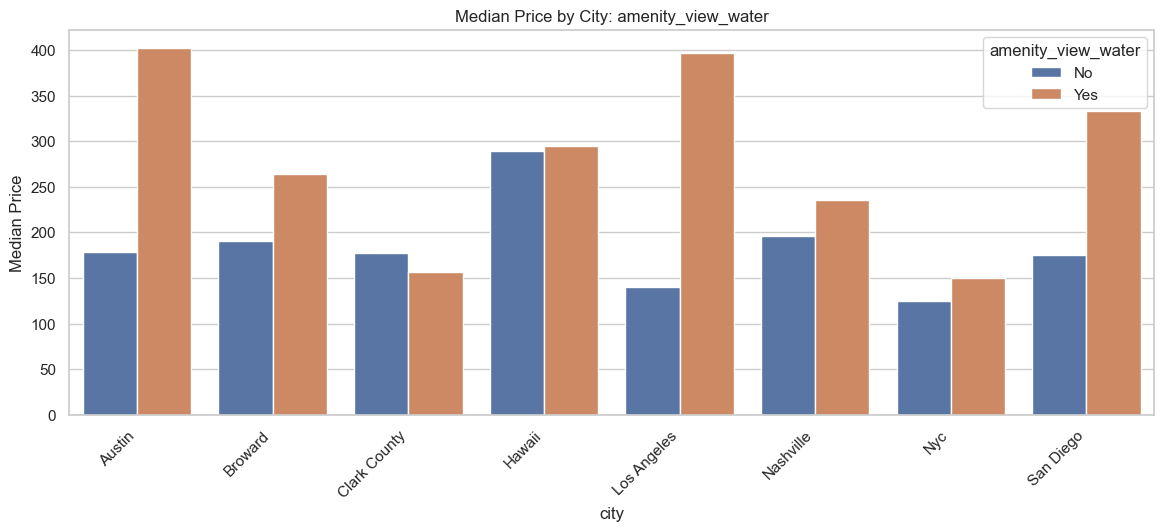

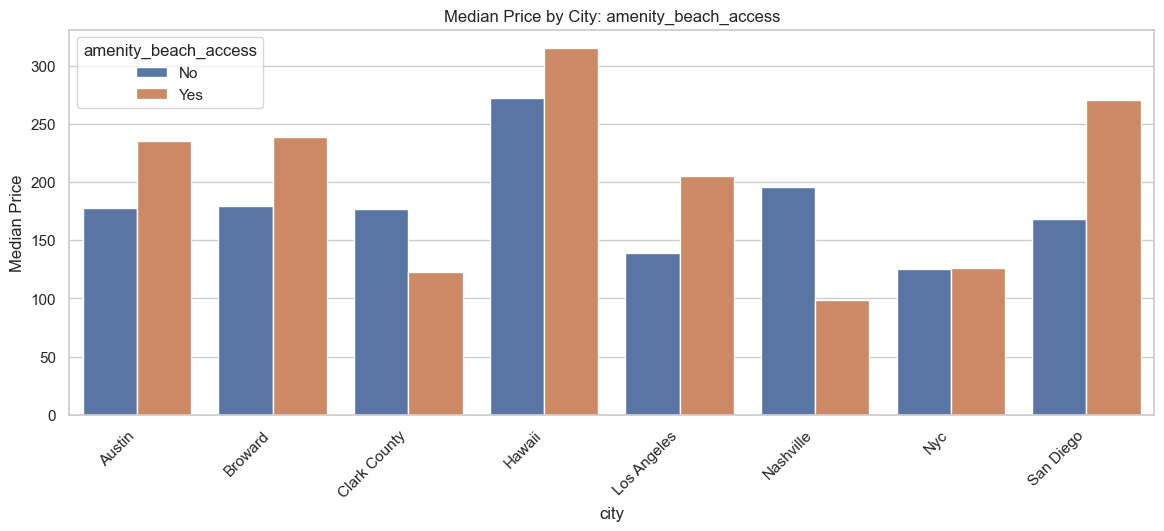

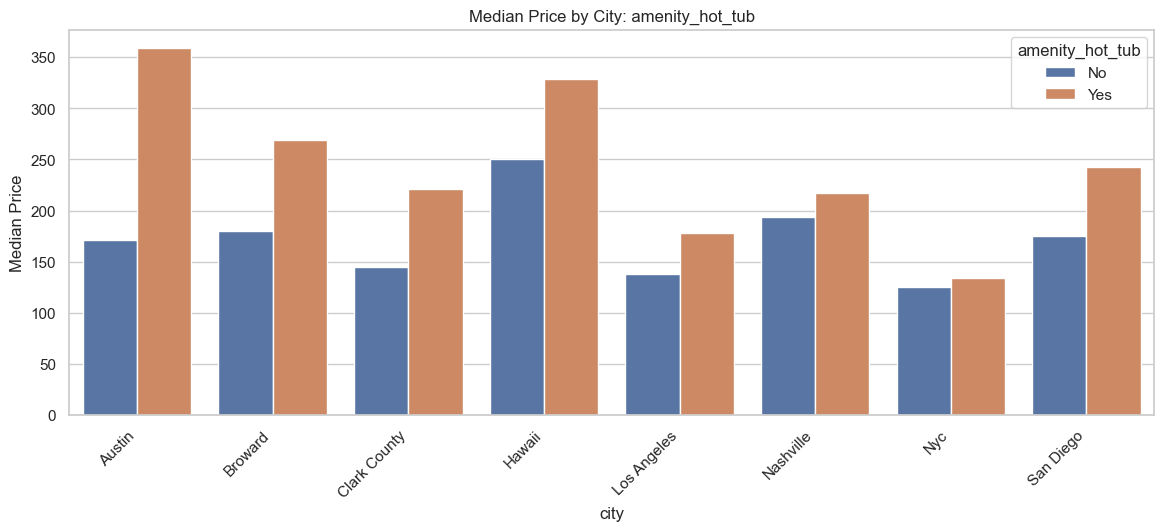

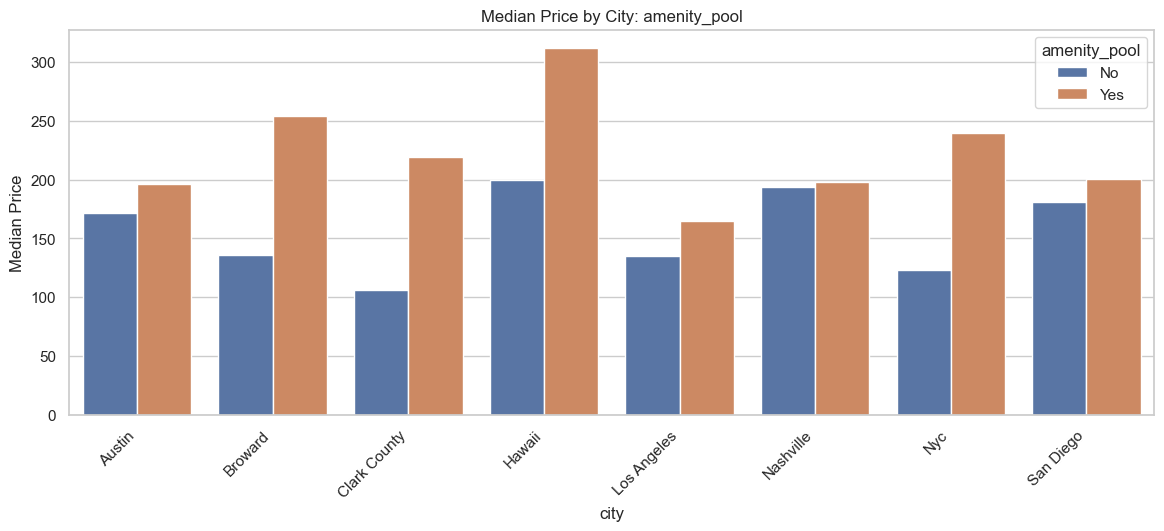

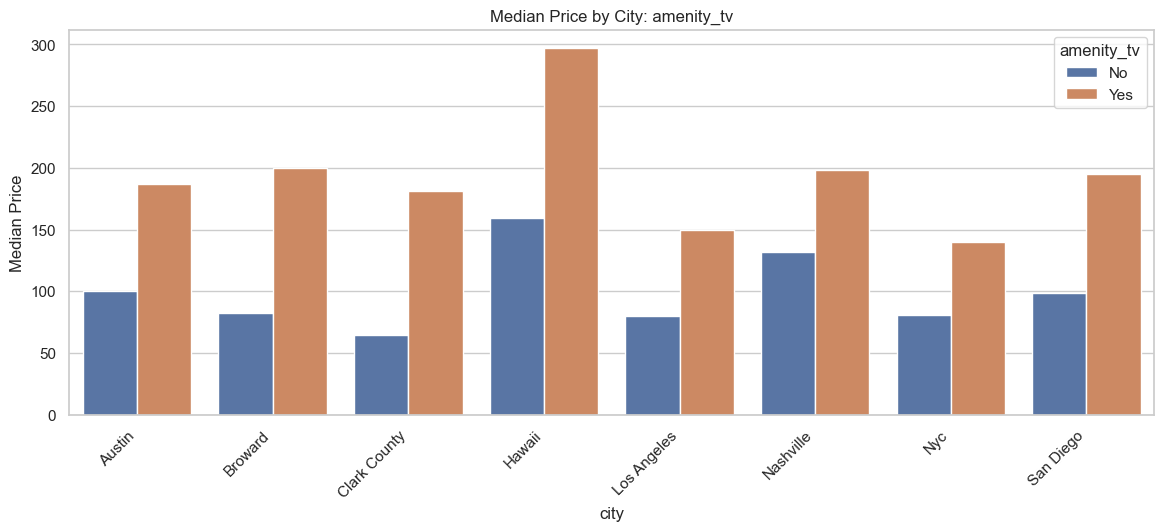

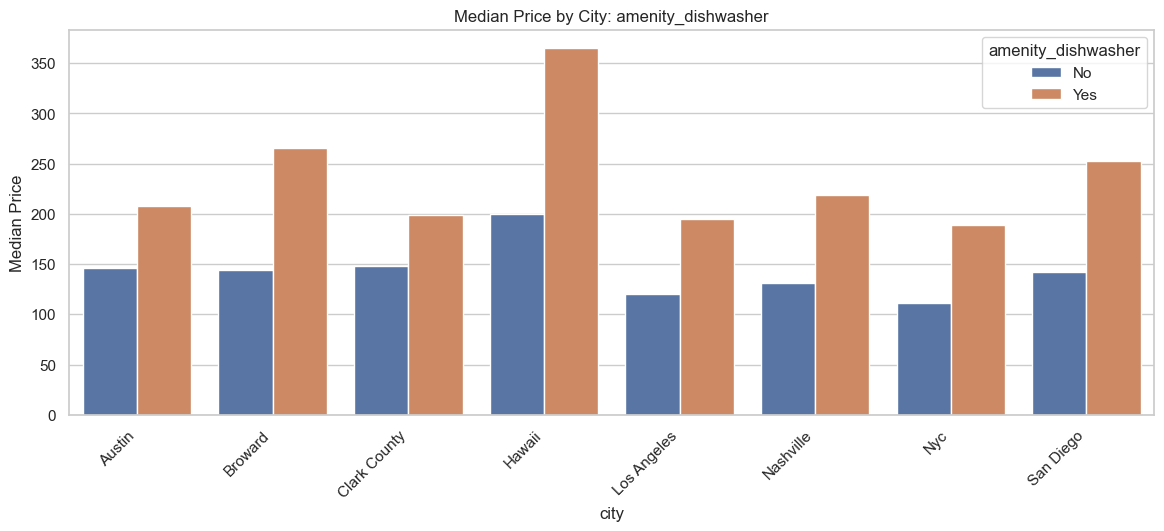

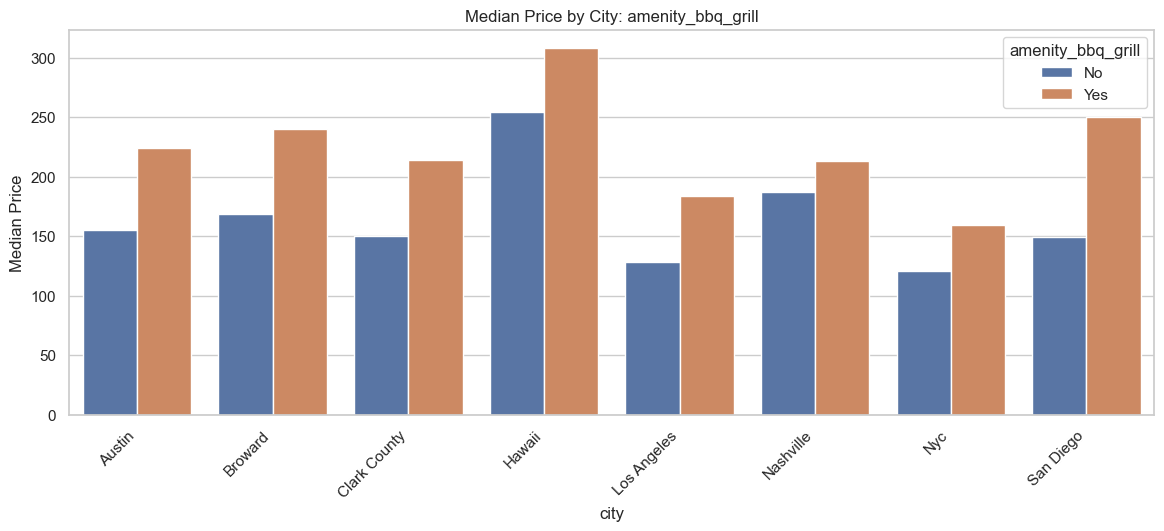

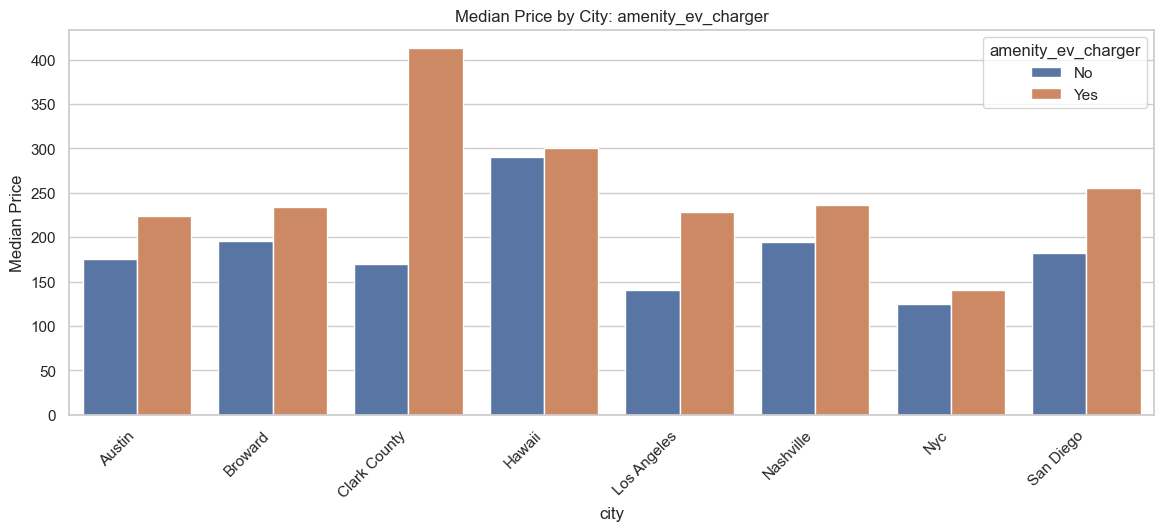

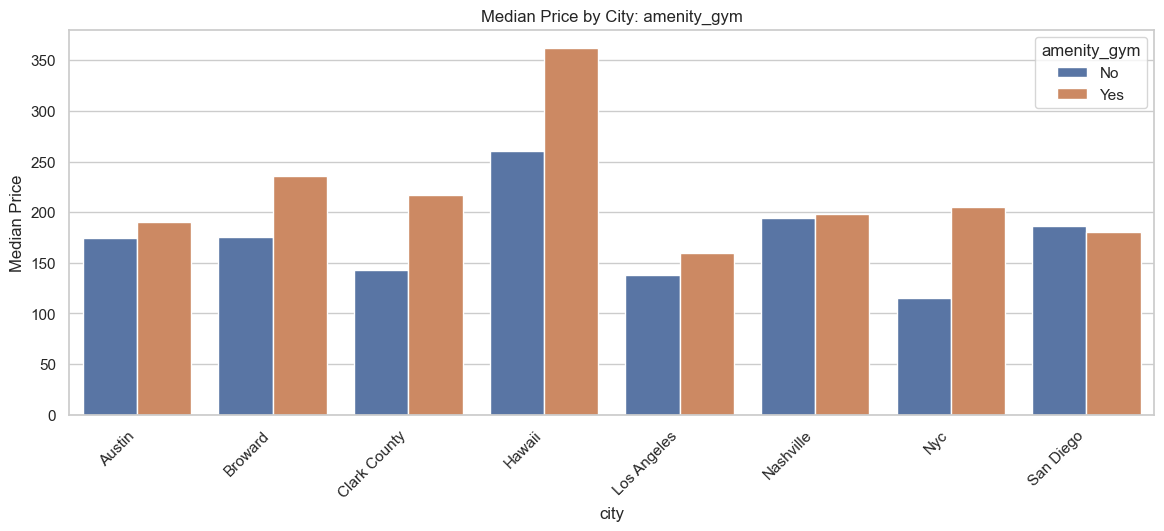

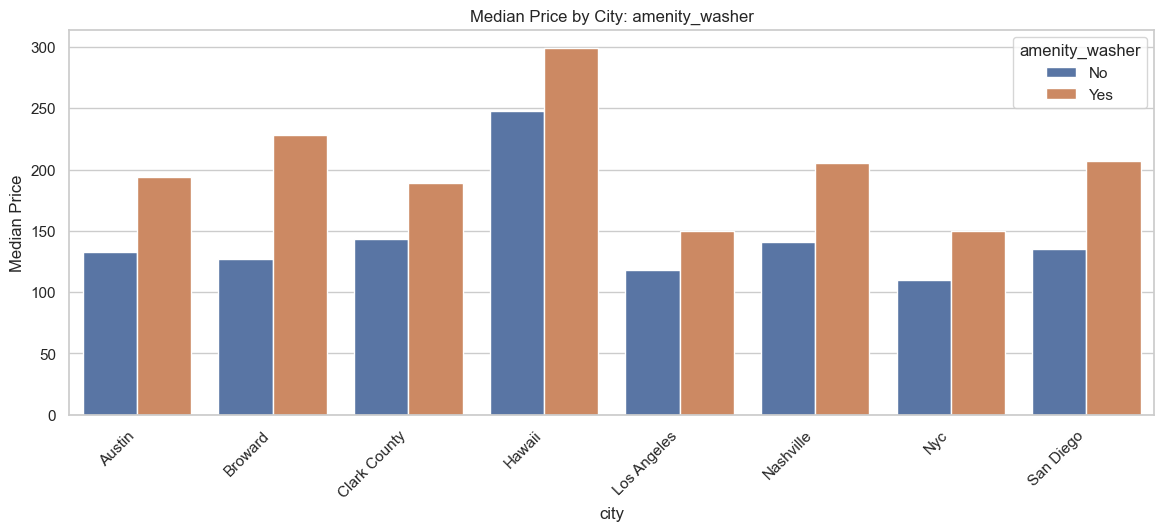

In [81]:
for amenity in top_price_amenities:

    plot_df = (
        df_clean[df_clean['city'].isin(top_cities)]
        .groupby(['city', amenity])['price']
        .median()
        .reset_index()
    )

    plot_df[amenity] = plot_df[amenity].map({
        0: 'No',
        1: 'Yes'
    })

    plt.figure(figsize=(14,5))

    sns.barplot(
        data=plot_df,
        x='city',
        y='price',
        hue=amenity
    )

    plt.title(f'Median Price by City: {amenity}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Median Price')
    plt.show()

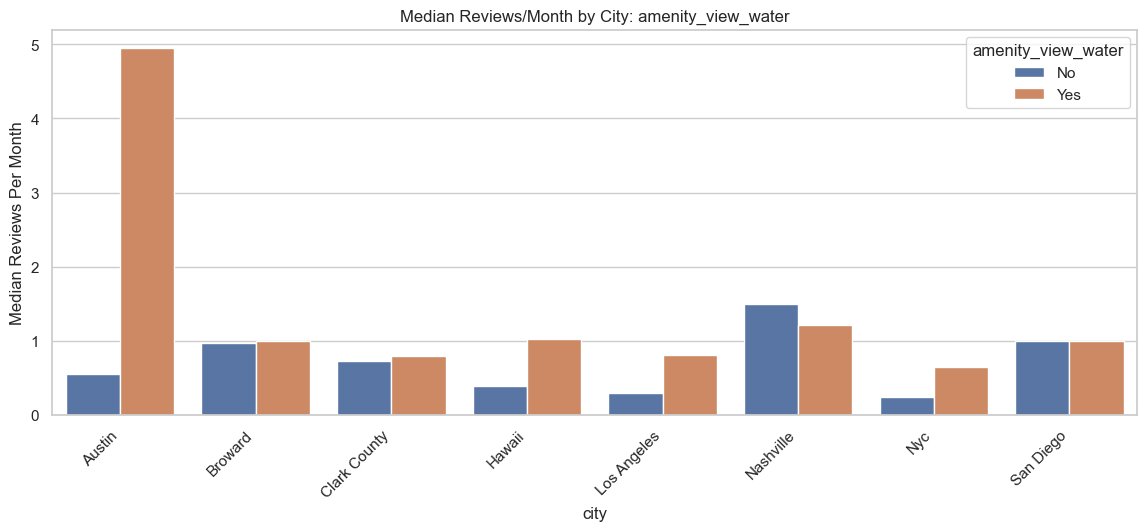

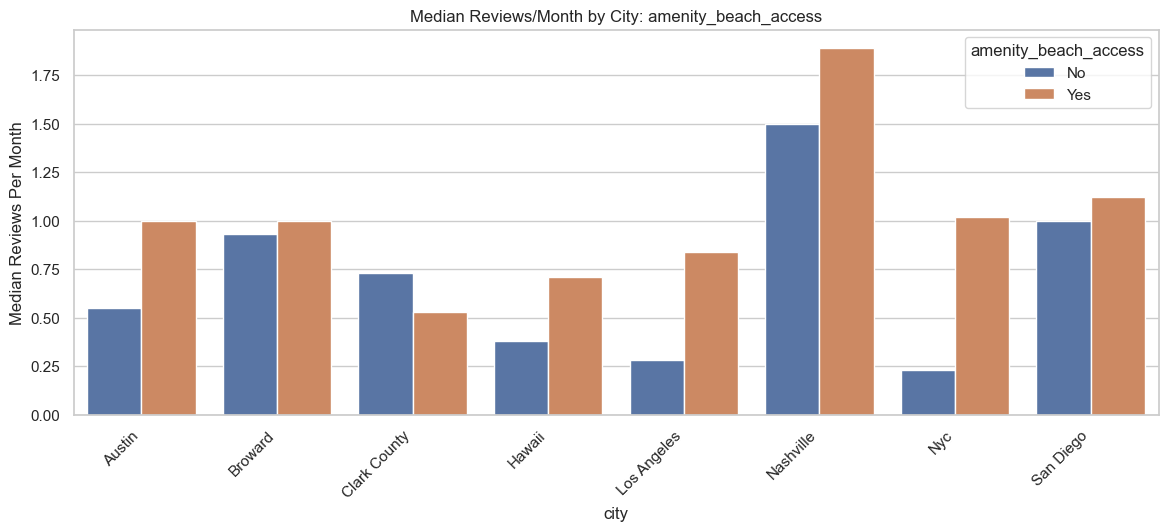

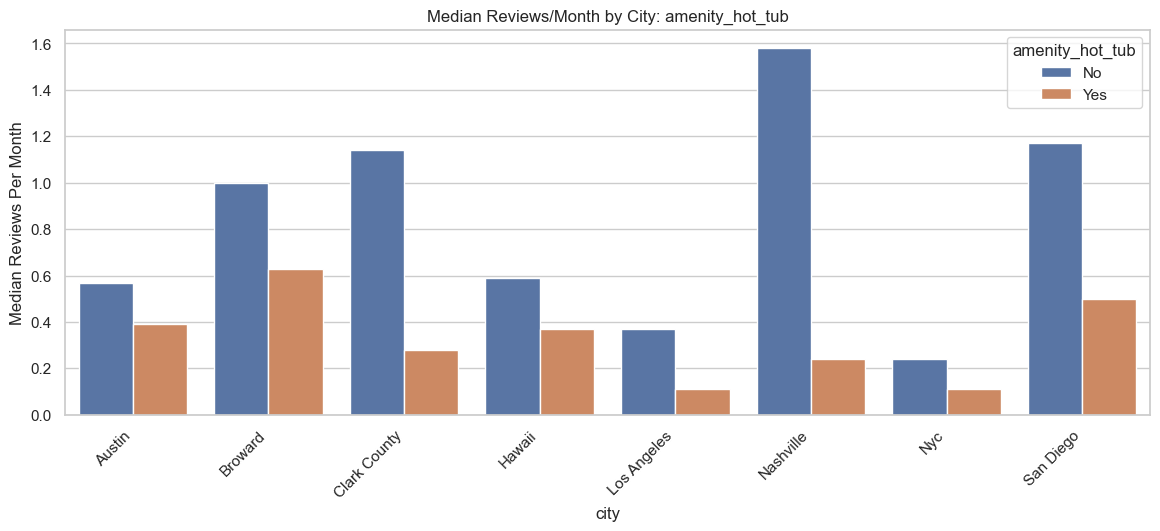

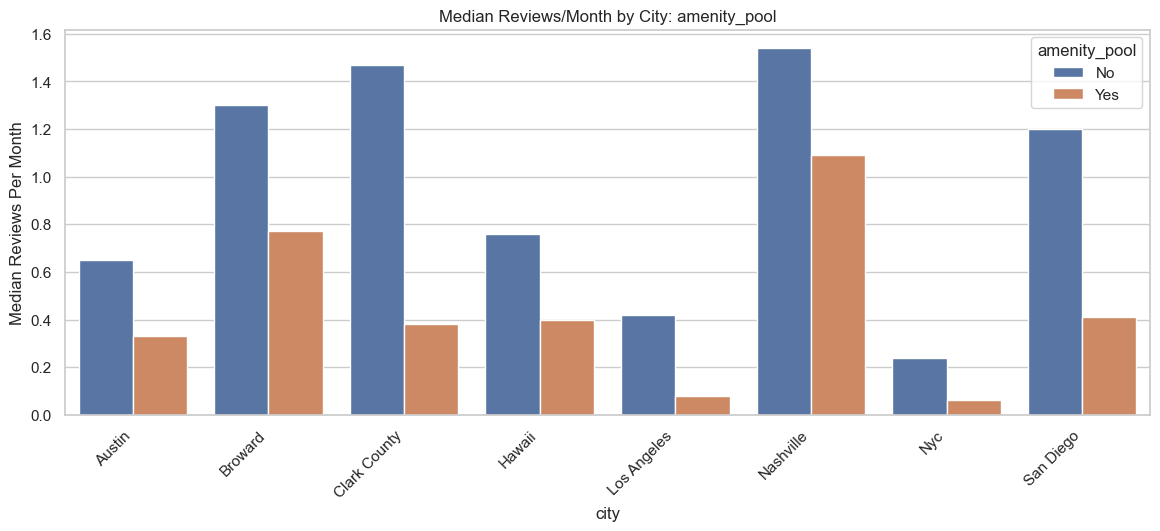

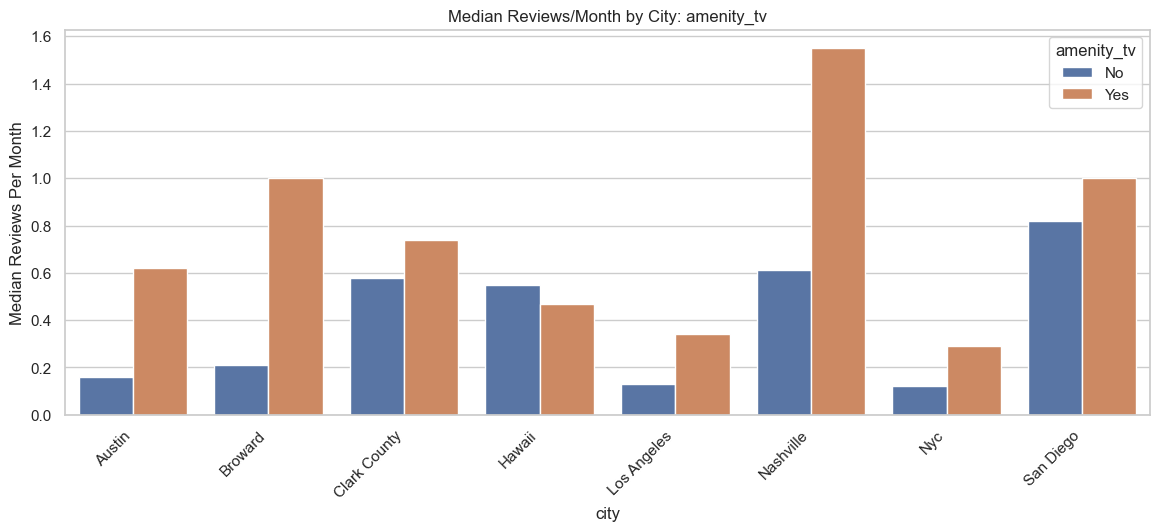

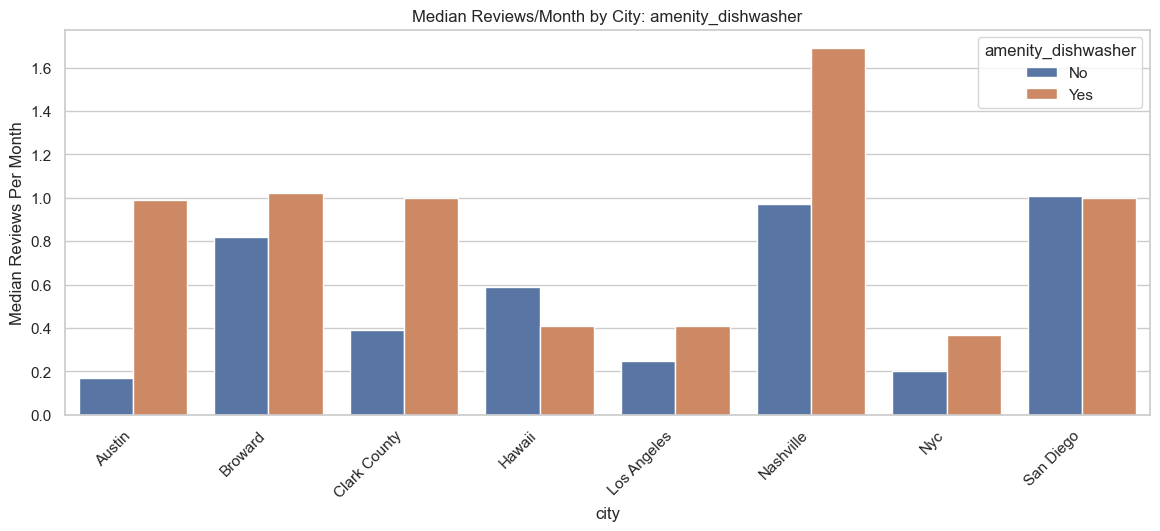

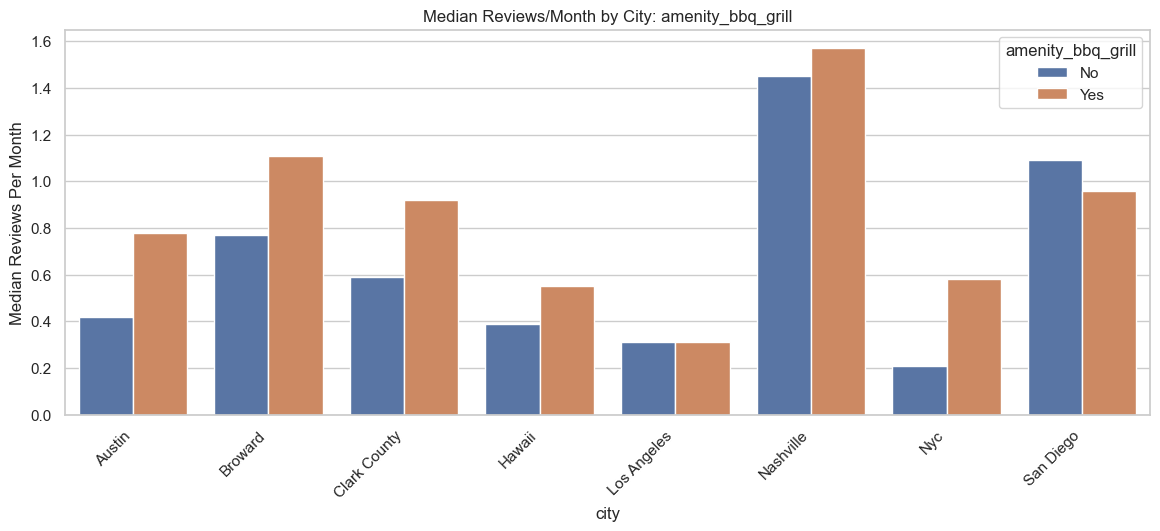

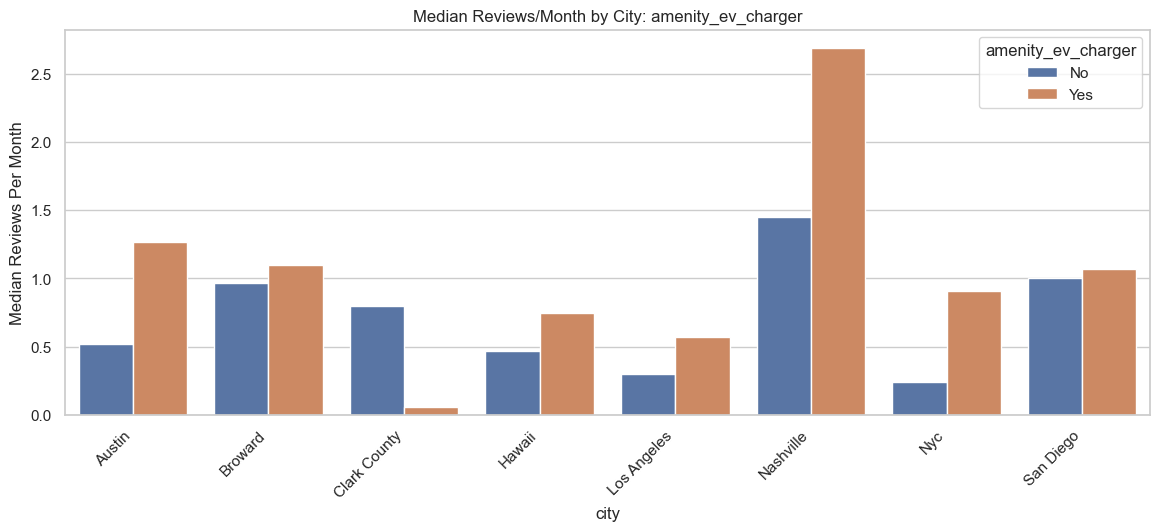

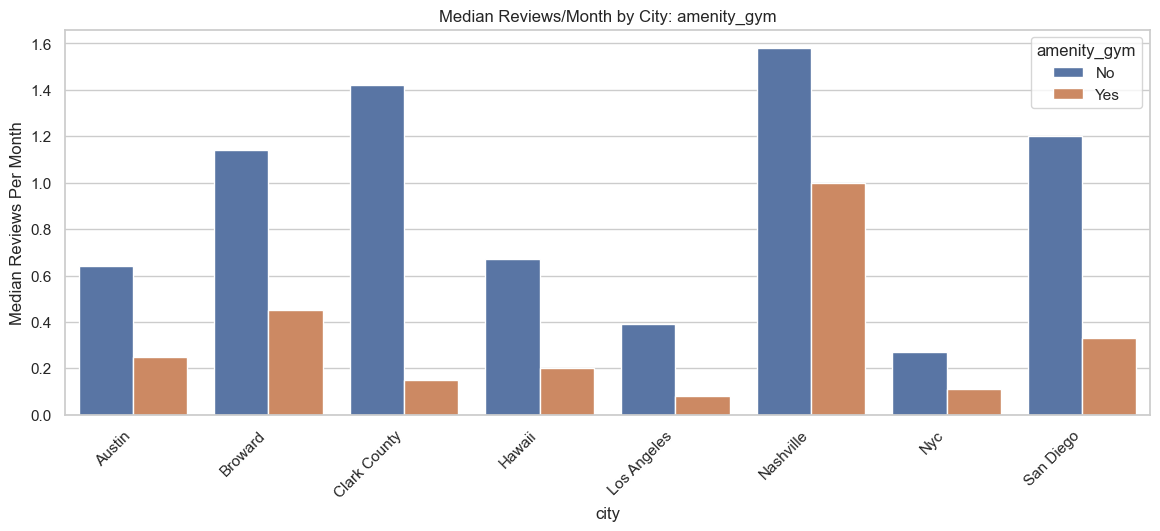

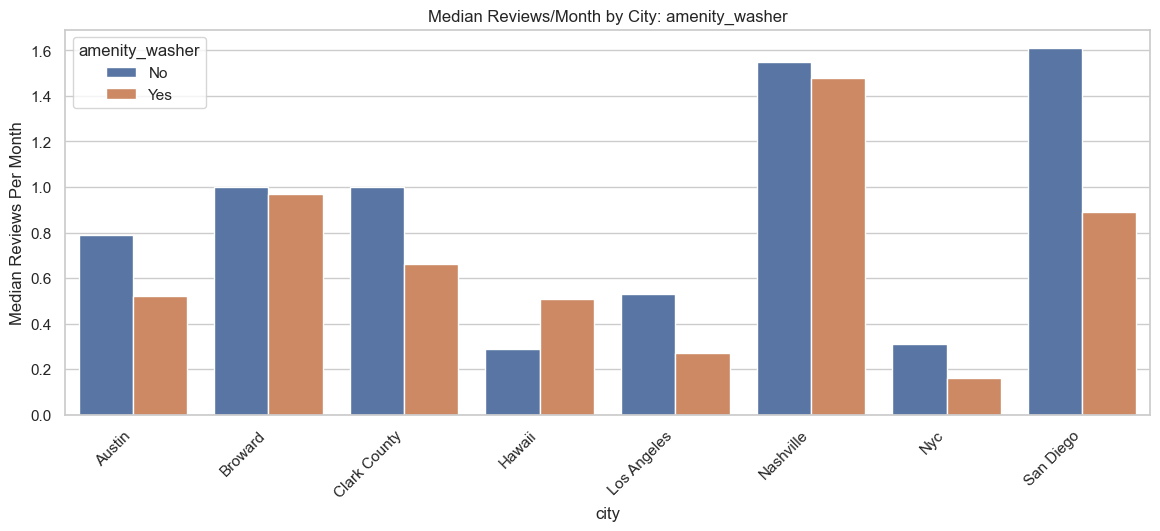

In [82]:
for amenity in top_price_amenities:

    plot_df = (
        df_clean[df_clean['city'].isin(top_cities)]
        .groupby(['city', amenity])['reviews_per_month']
        .median()
        .reset_index()
    )

    plot_df[amenity] = plot_df[amenity].map({
        0: 'No',
        1: 'Yes'
    })

    plt.figure(figsize=(14,5))

    sns.barplot(
        data=plot_df,
        x='city',
        y='reviews_per_month',
        hue=amenity
    )

    plt.title(f'Median Reviews/Month by City: {amenity}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Median Reviews Per Month')
    plt.show()

In [127]:
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

amenity_freq_df = (
    df_clean[amenity_cols]
    .mean()
    .sort_values(ascending=False)
    .to_frame(name='pct_of_listings')
)

display(amenity_freq_df.head(15))

,pct_of_listings
amenity_wifi,0.981483
amenity_smoke_alarm,0.939737
amenity_kitchen,0.893651
amenity_tv,0.885624
amenity_essentials,0.875239
amenity_air_conditioning,0.837590
amenity_hangers,0.793174
amenity_heating,0.786048
amenity_carbon_monoxide_alarm,0.779929
amenity_hair_dryer,0.779917


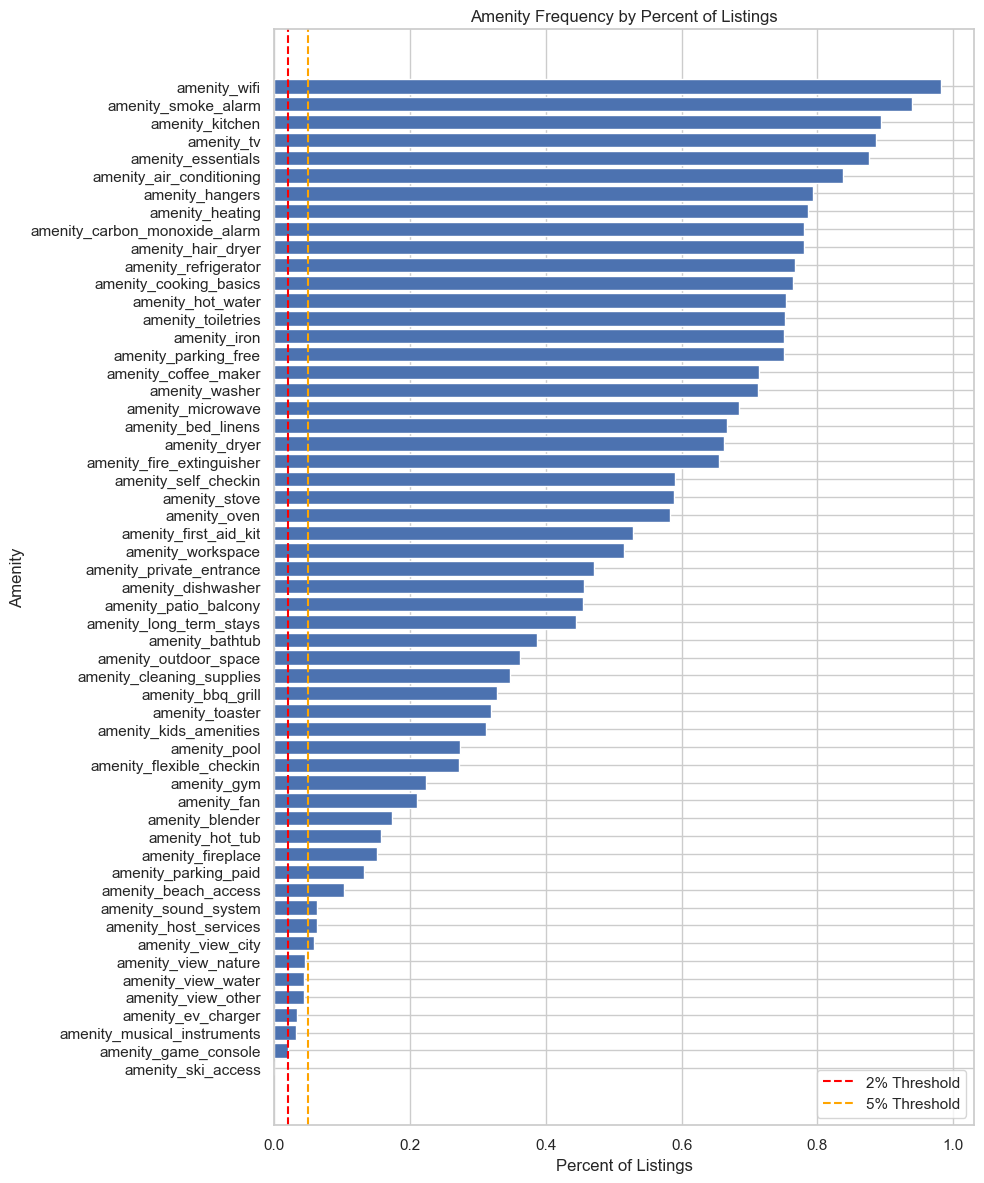

In [128]:
amenity_freq_sorted = amenity_freq_df.sort_values(by='pct_of_listings')

plt.figure(figsize=(10, 12))
plt.barh(
    amenity_freq_sorted.index,
    amenity_freq_sorted['pct_of_listings']
)

plt.axvline(0.02, color='red', linestyle='--', label='2% Threshold')
plt.axvline(0.05, color='orange', linestyle='--', label='5% Threshold')

plt.title('Amenity Frequency by Percent of Listings')
plt.xlabel('Percent of Listings')
plt.ylabel('Amenity')
plt.legend()
plt.tight_layout()
plt.show()

In [129]:
amenity_summary = []

for amenity in selected_amenities:
    group_yes = df_clean[df_clean[amenity] == 1]['price']
    group_no = df_clean[df_clean[amenity] == 0]['price']

    amenity_summary.append({
        'amenity': amenity,
        'frequency': df[amenity].mean(),
        'mean_price_yes': group_yes.mean(),
        'median_price_yes': group_yes.median(),
        'mean_price_no': group_no.mean(),
        'median_price_no': group_no.median(),
        'median_premium': group_yes.median() - group_no.median(),
        'mean_premium': group_yes.mean() - group_no.mean()
    })

amenity_summary_df = pd.DataFrame(amenity_summary)

In [165]:
amenity_summary_df.sort_values('median_premium', ascending=False).head(10)

,amenity,frequency,mean_price_yes,median_price_yes,mean_price_no,median_price_no,median_premium,mean_premium
50,amenity_view_water,0.044410,392.867391,285.0,233.867459,150.0,135.0,158.999932
45,amenity_beach_access,0.103451,370.726263,265.0,225.912208,149.0,116.0,144.814055
42,amenity_hot_tub,0.159639,381.380079,250.0,214.519322,145.0,105.0,166.860757
37,amenity_pool,0.275352,353.751183,232.0,198.299947,136.0,96.0,155.451237
3,amenity_tv,0.885930,253.573302,167.0,142.249343,85.0,82.0,111.323959
28,amenity_dishwasher,0.457399,292.742843,202.0,197.201385,125.0,77.0,95.541458
34,amenity_bbq_grill,0.329506,311.476933,211.0,206.240242,136.0,75.0,105.236691
52,amenity_ev_charger,0.033951,361.991104,214.0,236.607087,152.0,62.0,125.384018
39,amenity_gym,0.224620,315.744695,200.0,219.196945,145.0,55.0,96.547750
17,amenity_washer,0.713451,258.634934,175.0,196.666410,121.0,54.0,61.968524


In [131]:
# low frequency, high median premium: Rare but potentially premium amenities worth reviewing

amenity_summary_df[
        (amenity_summary_df['frequency'] < 0.10) &
        (amenity_summary_df['median_premium'] > 50)
    ].sort_values('median_premium', ascending=False)

,amenity,frequency,mean_price_yes,median_price_yes,mean_price_no,median_price_no,median_premium,mean_premium
50,amenity_view_water,0.044410,392.867391,285.0,233.867459,150.0,135.0,158.999932
52,amenity_ev_charger,0.033951,361.991104,214.0,236.607087,152.0,62.0,125.384018
49,amenity_view_nature,0.045524,313.234895,202.0,237.400585,151.0,51.0,75.834310


In [132]:
for amenity in binary_amenities:
    group_yes = df_clean[df_clean[amenity] == 1]['price']
    group_no = df_clean[df_clean[amenity] == 0]['price']

    stat, p = ttest_ind(group_yes, group_no, equal_var=False)

    print(f'\n{amenity.upper()}')
    print(f'Mean Price w/ {amenity}: ${group_yes.mean():.2f}')
    print(f'Median Price w/ {amenity}: ${group_yes.median():.2f}')
    print(f'Mean Price w/o {amenity}: ${group_no.mean():.2f}')
    print(f'Median Price w/o {amenity}: ${group_no.median():.2f}')
    print(f'p-value: {p:.10f}')


AMENITY_VIEW_WATER
Mean Price w/ amenity_view_water: $392.87
Median Price w/ amenity_view_water: $285.00
Mean Price w/o amenity_view_water: $233.87
Median Price w/o amenity_view_water: $150.00
p-value: 0.0000000000

AMENITY_BEACH_ACCESS
Mean Price w/ amenity_beach_access: $370.73
Median Price w/ amenity_beach_access: $265.00
Mean Price w/o amenity_beach_access: $225.91
Median Price w/o amenity_beach_access: $149.00
p-value: 0.0000000000

AMENITY_HOT_TUB
Mean Price w/ amenity_hot_tub: $381.38
Median Price w/ amenity_hot_tub: $250.00
Mean Price w/o amenity_hot_tub: $214.52
Median Price w/o amenity_hot_tub: $145.00
p-value: 0.0000000000

AMENITY_POOL
Mean Price w/ amenity_pool: $353.75
Median Price w/ amenity_pool: $232.00
Mean Price w/o amenity_pool: $198.30
Median Price w/o amenity_pool: $136.00
p-value: 0.0000000000

AMENITY_TV
Mean Price w/ amenity_tv: $253.57
Median Price w/ amenity_tv: $167.00
Mean Price w/o amenity_tv: $142.25
Median Price w/o amenity_tv: $85.00
p-value: 0.0000000

### Amenity Review


<b>Amenity Frequency</b>: helps show how common each feature is, but frequency doesn't tell the full story. 
To decide which amenities to keep, I also compared how much each amenity impacts listing price. 
This helped identify rare amenities that appear in fewer listings but may still be important because they are associated with higher prices.

* While premium amenities generally result in higher average prices, the demand for premium amenities isn't universal -- they're specific to cities/markets.
* For example, Austin listings with a water view outperformed listings without (nearly 5 bookings/month compared to .5 bookings/month), whereas other cities were less affected by listings with water views.
* The study of price vs amenity wasn't really helpful because it naturally makes sense that a listing with more/premium amenities can charge a higher price. The data is isolated, so it doesn't really tell me if it's a larger home (which statistically doesn't book as often, or if it's located somewhere outside of the city center, which could also have lower demand. Overall it's inconclusive.
* I would be more interested in seeing what combination of amenities perform best, or which amenities are actually most important to be consistently booked.


### Explore Host Features

In [134]:
quality_features = [
    'host_is_superhost',
    'instant_bookable',
    'host_response_time_ord',
    'review_scores_rating']

df_clean[quality_features + ['price']].describe(include='all')

,host_is_superhost,instant_bookable,host_response_time_ord,review_scores_rating,price
count,266350.000000,266350.000000,266350.000000,266350.000000,266350.000000
mean,0.365099,0.328252,2.082110,3.748910,240.840533
std,0.481459,0.469578,1.513422,1.975605,287.509424
min,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,4.000000,95.000000
50%,0.000000,0.000000,3.000000,4.800000,154.000000
75%,1.000000,1.000000,3.000000,4.970000,271.000000
max,1.000000,1.000000,3.000000,5.000000,3150.000000


In [160]:
from scipy.stats import ttest_ind

binary_quality_features = ['host_is_superhost', 'instant_bookable']

for col in binary_quality_features:
    yes_group = df[df[col] == 1]['price'].dropna()
    no_group = df[df[col] == 0]['price'].dropna()

    stat, p = ttest_ind(yes_group, no_group, equal_var=False)

    print(f'\n--- {col.replace("_", " ").title()} ---')
    print(f'Mean price when TRUE: ${yes_group.mean():.2f}')
    print(f'Median price when TRUE: ${yes_group.median():.2f}')
    print(f'Mean price when FALSE: ${no_group.mean():.2f}')
    print(f'Median price when FALSE: ${no_group.median():.2f}')
    print(f'p-value: {p:.10f}')


--- Host Is Superhost ---
Mean price when TRUE: $260.81
Median price when TRUE: $164.00
Mean price when FALSE: $305.93
Median price when FALSE: $150.00
p-value: 0.0000000000

--- Instant Bookable ---
Mean price when TRUE: $369.97
Median price when TRUE: $180.00
Mean price when FALSE: $249.93
Median price when FALSE: $149.00
p-value: 0.0000000000


In [139]:
from scipy.stats import ttest_ind

for col in binary_quality_features:
    group_yes = df[df_clean[col] == 1]['price'].dropna()
    group_no = df[df[col] == 0]['price'].dropna()

    stat, p = ttest_ind(group_yes, group_no, equal_var=False)

    print(f'\n{col.upper()}')
    print(f'Mean price when {col}=1: ${group_yes.mean():.2f}')
    print(f'Median price when {col}=1: ${group_yes.median():.2f}')
    print(f'Mean price when {col}=0: ${group_no.mean():.2f}')
    print(f'Median price when {col}=0: ${group_no.median():.2f}')
    print(f'p-value: {p:.10f}')


HOST_IS_SUPERHOST
Mean price when host_is_superhost=1: $260.81
Median price when host_is_superhost=1: $164.00
Mean price when host_is_superhost=0: $305.93
Median price when host_is_superhost=0: $150.00
p-value: 0.0000000000

INSTANT_BOOKABLE
Mean price when instant_bookable=1: $369.97
Median price when instant_bookable=1: $180.00
Mean price when instant_bookable=0: $249.93
Median price when instant_bookable=0: $149.00
p-value: 0.0000000000


In [141]:
df_clean['host_response_time_ord'].value_counts(dropna=False)

host_response_time_ord
 3.0    177528
-1.0     45405
 2.0     27093
 1.0     13205
 0.0      3119
Name: count, dtype: int64

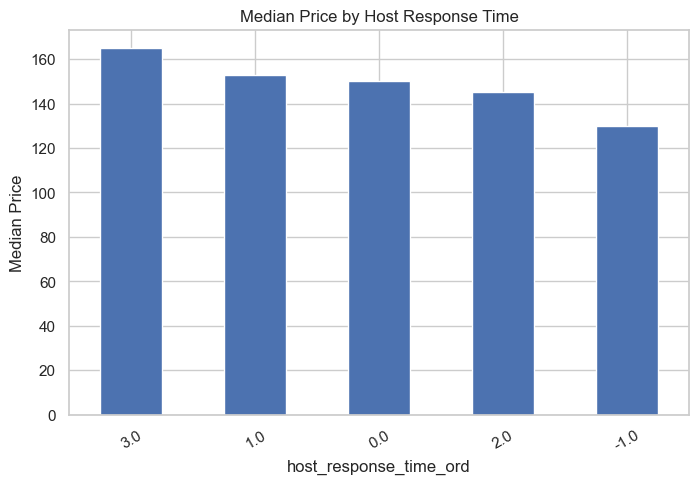

In [145]:
response_medians = (
    df.groupby('host_response_time_ord')['price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
response_medians.plot(kind='bar')
plt.title('Median Price by Host Response Time')
plt.ylabel('Median Price')
plt.xticks(rotation=30)
plt.show()

In [146]:
df_clean['review_scores_rating'].describe()

count    266350.000000
mean          3.748910
std           1.975605
min           0.000000
25%           4.000000
50%           4.800000
75%           4.970000
max           5.000000
Name: review_scores_rating, dtype: float64

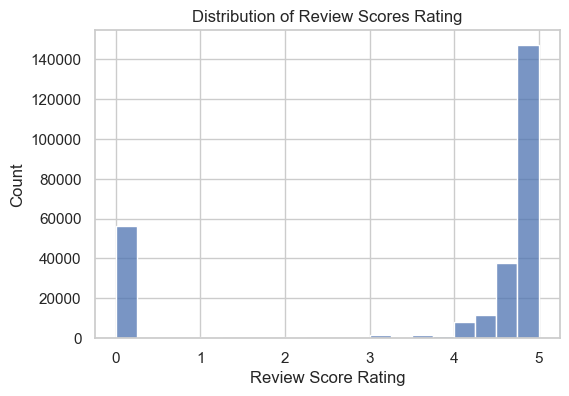

In [148]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['review_scores_rating'].dropna(), bins=20)
plt.title('Distribution of Review Scores Rating')
plt.xlabel('Review Score Rating')
plt.show()

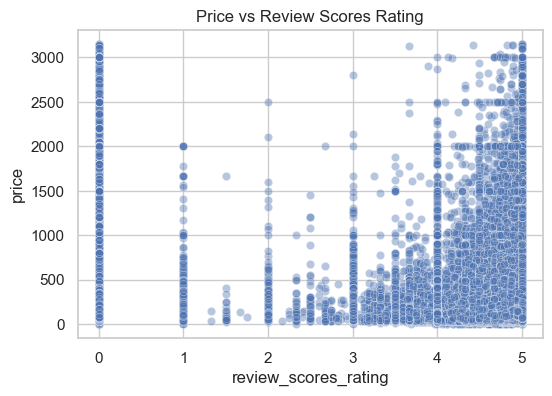

In [152]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='review_scores_rating', y='price', alpha=0.4)
plt.title('Price vs Review Scores Rating')
plt.show()

In [156]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_clean['host_is_superhost'], df_clean['instant_bookable'])
display(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p:.10f}')

instant_bookable,0,1
host_is_superhost,,
0.0,111900,57206
1.0,67020,30224


Chi-square statistic: 211.302
p-value: 0.0000000000


In [158]:
contingency = pd.crosstab(df_clean['host_is_superhost'], df_clean['host_response_time_ord'])
display(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p:.10f}')

host_response_time_ord,-1.0,0.0,1.0,2.0,3.0
host_is_superhost,,,,,
0.0,42974,3036,10405,17309,95382
1.0,2431,83,2800,9784,82146


Chi-square statistic: 29190.513
p-value: 0.0000000000


In [159]:
quality_summary = []

for col in ['host_is_superhost', 'instant_bookable']:
    group_yes = df[df[col] == 1]['price']
    group_no = df[df[col] == 0]['price']

    quality_summary.append({
        'feature': col,
        'median_price_yes': group_yes.median(),
        'median_price_no': group_no.median(),
        'median_difference': group_yes.median() - group_no.median(),
        'mean_price_yes': group_yes.mean(),
        'mean_price_no': group_no.mean(),
        'mean_difference': group_yes.mean() - group_no.mean(),
        'frequency_yes': df[col].mean()
    })

quality_summary_df = pd.DataFrame(quality_summary)
display(quality_summary_df)

,feature,median_price_yes,median_price_no,median_difference,mean_price_yes,mean_price_no,mean_difference,frequency_yes
0,host_is_superhost,164.0,150.0,14.0,260.812074,305.925497,-45.113423,0.364258
1,instant_bookable,180.0,149.0,31.0,369.973557,249.928623,120.044933,0.329576


In [167]:
df_clean.shape

(266350, 83)

In [171]:
df_clean.to_csv('../data/processed/airbnb_eda_clean.csv', index=False)

### Analysis
* The mean price for superhost vs not superhost was interesting since it was higher. There could be some large/luxury listings driving up the mean, where the host is not a superhost.
* I think it makes most sense to focus on median when analyzing the Airbnb listings.

## Modeling Implications / Feature Selection

### Dataset Preparation Summary
1. Removed inactive / extreme commercial listings (skewing data)
2. Applied percentile-based outlier filter

### Key Findings
* Larger listings = higher prices but are book less often, suggesting a tradeoff between ADR and demand.
* Premium amenities like water views, beach access, hot tubs, and pools are linked to with the largest price premiums.
* Convenience/basic-use amenities appear more strongly associated with booking frequency than luxury amenities.
* Location impacts both price and booking performance -- will look further into this
* convenience amenities drive booking frequency
* host/listing quality features show modest relationship

Based on EDA, the most predictive variables for price and booking performance are property attributes (beds/room type), location, and select amenities which I will look into when modeling.


### Features to Keep for Modeling
* Capacity: accommodates, bedrooms, bathrooms
* Location: city, lat/long
* Listing type: room type (entire place, shared, private)
* Premium amenities with high price signal
* Host/listing quality features (superhost, instant bookable, review rating)

### Features Excluded / Reduced
* IDs / URLs / non-predictive metadata
* Highly sparse amenities (less than 5% of listings)
* Basic/common amenities with little differentiating power

### Next Steps
1. Prep selected features for predictive modeling
2. Address multicollinearity among correlated variables (beds, bedrooms, bathrooms)
3. Test regression models
4. Evaluate model performance to identify the strongest drivers of Airbnb pricing
5. Add image analysis